In [1]:
import os, bz2
import pickle
from glob import iglob
import pandas as pd
from scipy.stats import fisher_exact
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
samples_in_cluster = ["GUI_0210315","C16-20274-GH","CM.347_WGS","C16-20459-TZ","A27_02_1FE","A13_03_1FE","CM.514_WGS","GUI_200603","CM.536_WGS","G88710","C16-20288-GH","GUI_0210118","GUI_110104","DHAK_C19_M","83597_31","83433_31","83351_31","83860_31","C16-20431-TZ","83544_31","83331_31","A94_01_1FE","C16-20625-TZ","83821_31","C16-20345-TZ","83355_31","83403_31","C16-20609-TZ","WL.43.ST","83474_31","C16-20554-TZ","C16-20439-TZ","C16-20602-TZ","83438_31","C16-20153-TZ","83340_31","83842_31","C16-20548-TZ","C16-20055-TZ","C16-20440-TZ","C16-20441-TZ","CM.47_WGS","C16-20549-TZ","H7","COL_2MH","C16-20371-TZ","C16-20387-TZ","C16-20452-TZ","C16-20603-TZ","C16-20493-TZ","C16-20429-TZ","C16-20470-TZ","GUI_130401","GUI_0140112","V12_01_2FE","A34_01_1FE","U_VS-1592-367","A46_01_1FE","C16-20205-TZ","DHAK_C4_M","DHAK_C3_M","V50_02_1FE","A75_02_1FE","A39_01_1FE","V19_02_2FE","V30_01_1FE","A88_02_1FE","A56_01_1FE","A90_04_1FE","A10_02_1FE","A04_01_1FE","V31_01_2FE","A20_03_1FE","V36_02_2FE","A46_02_1FE","A49_01_1FE","A24_04_1FE","GUI_80410","NCS-012-Stool-maternal3_microbiome","DY.419.D01","V53_02_1FE","U_VS-1506-333","A36_01_1FE","A14_01_1FE","V54_01_1FE","A28_02_1FE","V40_01_1FE","A23_01_1FE","A58_01_1FE","A07_01_1FE","V01_01_1FE","A83_02_1FE","A22_01_1FE","A89_02_1FE","A09_02_1FE","W2.1.ST","A25_01_1FE","A69_02_1FE","A70_01_1FE","A94_03_1FE","A44_01_1FE","A01_02_1FE","A69_01_1FE","GUI_140302","GUI_70113","V18_02_1FE","A90_03_1FE","A40_02_1FE","A53_01_1FE","SAMEA4719815","SAMEA4719807","SAMEA4719798","SAMEA4719790","SAMEA4719791","SAMEA4719783","SAMEA4719782","SAMEA4719787","C16-20049-GH","C16-20273-GH","C16-20112-GH","C16-20345-GH","GUI_180104","SAMEA4719784","CM.512_WGS","CM.418_WGS","SAMEA4719777","SAMEA4719808","SAMEA4719762","CM.366_WGS","GUI_80418","C16-20363-GH","C16-20001-GH","C16-20292-GH","C16-20029-GH","A13_01_1FE","GUI_200401","GUI_0080105","GUI_200402","GUI_200412","GUI_2100107","C16-20214-GH","CM.285_WGS","CM.342_WGS","C16-20124-GH","GUI_200108","GUI_200107","C16-20127-GH","C16-20218-GH","C16-20316-GH","C16-20111-GH","C16-20394-GH","GUI_140203","GUI_100104","TRAVELRES64","C16-20402-GH","CM.152_WGS","C16-20092-GH","CM.486_WGS","SAMEA4719763","C16-20012-GH","C16-20113-GH","CM.574_WGS","CM.294_WGS","C16-20081-TZ","PNP_Main_277","SAMEA4719778","SAMEA4719769","SAMEA4719799","SAMEA4719781","CM.328_WGS","CM.438_WGS","C16-20358-GH","C16-20243-GH","CM.403_WGS","C16-20108-GH","C16-20362-GH","C16-20241-GH","C16-20038-GH","C16-20150-GH","83936_31","SAMEA4719803","CM.177_WGS","SAMEA4719809","A81_03_1FE","CM.310_WGS","C16-20432-TZ","83945_31","C16-20474-TZ","C16-20268-TZ","C16-20475-TZ","C16-20073-GH","C16-20050-GH","C16-20047-GH","SAMEA2055108","CCIS41692898ST-4-0","83884_31","83587_31","C16-20065-TZ","C16-20494-TZ","83579_31","83969_31","C16-20416-TZ","MH0144","83816_31","COL_10MH","SID08K_237","NO03","SID060201","SID030602","SID080304","SID190104","SID100401","MH0100","83577_31","83951_31","SID250502","SID240201","SID250501","SID240104","COL_11MH","SID100304","SID080104","SID210102","SID100404","MSM79H5S","SID210401","SID140301","SID020202","SID010202","SID010201","SID020201","SID030102","SID010401","SID030601","SID240101","SID190101","SID240102","SID250301","WL.17.ST","W1.53.ST","W2.46.ST","W1.20.ST","W1.27.ST","M2.51.ST","M1.27.ST","WL.37.ST","WL.33.ST","M2.45.ST","M2.50.ST","WL.8.ST","W1.26.ST","W2.33.ST","W3.21.ST","M2.36.ST","W2.15.ST","W2.23.ST","W2.67.ST","W2.11.ST","W1.42.ST","M1.25.ST","WL.36.ST","WL.35.ST","M1.24.ST","W2.62.ST","W1.33.ST","WL.26.ST","WL.5.ST","M2.37.ST","M2.39.ST","M2.58.ST","M2.40.ST","M1.57.ST","M2.49.ST","M1.5.ST","M1.59.ST","M1.7.ST","W1.9.ST","M1.22.ST","W2.63.ST","W1.39.ST","M2.38.ST","W2.45.ST","M1.38.ST","M2.11.ST","M1.65.ST","W1.36.ST","W2.13.ST","WL.20.ST","WL.10.ST","W1.21.ST","W1.3.ST","W1.38.ST","M1.3.ST","W2.61.ST","W3.19.ST","WL.9.ST","W1.11.ST","W2.52.ST","WL.7.ST","W2.21.ST","W2.19.ST","W3.22.ST","W1.31.ST","W1.15.ST","W2.8.ST","W3.17.ST","C16-20437-TZ","W1.6.ST","W2.25.ST","W2.26.ST","M2.3.ST","M2.56.ST","M1.64.ST","M1.62.ST","M1.63.ST","W3.20.ST","W2.69.ST","W2.44.ST","W2.59.ST","WL.2.ST","W3.23.ST","W1.34.ST","WL.12.ST","W2.5.ST","W1.13.ST","WL.15.ST","WL.44.ST","M2.63.ST","WL.45.ST","M1.48.ST","M1.6.ST","W2.47.ST","W2.53.ST","W2.54.ST","WL.14.ST","W1.4.ST","W1.44.ST","W1.37.ST","W2.34.ST","W2.6.ST","W1.18.ST","W2.48.ST","C16-20370-TZ","83546_31","C16-20627-TZ","C16-20095-TZ","COL_5MH","SM01","SM11","SID030202","SID210204","SID240304","SID060301","SID100202","SID080101","SID100301","SM30","SM31","SM37","COL_13MH","SM02","SM41","HCO02","SID030702","GUI_0140115","SID010302","SID020302","SID020301","SID010301","SID100402","SID210101","SID210304","SID030704","SID090201","W2.68.ST","WL.28.ST","M1.52.ST","M2.52.ST","M1.42.ST","WL.30.ST","M2.31.ST","M2.57.ST","M1.61.ST","W2.36.ST","MMRS65742083ST-27-0-0","SAMEA7045445","SAMEA7045540","HCO74","PNP_Main_632","SIDVOV16_metag","DHAK_C24_M","DHAK_HBV","DHAK_HBG","DHAK_HDE","JAS_9","LDK_4","LDK_6","CM_A04_M0_18","JAS_5","JAS_4","SID88dfb37e-7ae6-11e9-a106-68b59976a384","KHG_1","JAS_8","SAMEA7045801","DHAK_HT","KHG_9","DHAK_HB","LDK_2","JAS_7","SID760171c0-7ae6-11e9-a106-68b59976a384","KHG_8","JAS_6","PNP_Main_573","JAS_10","JAS_3","KHG_6","DHAK_HCM","GupDM_HCM","KHG_5","SID713A081-11-0-0","SID713A081-11-90-0","PNP_Main_81","GupDM_HP","DHAK_HP","c0528962-7ae6-11e9-a106-68b59976a384","SAMEA7045525","LDK_8","TRAVELRES8","SID8d1d85c4-7ae6-11e9-a106-68b59976a384","SID11188967_SF06","SID11188967_SF05","KHG_11","KHG_10","CM_D39_I1_18","CM_D13_M0_18","CM_D04_I1_18","CM_D10_I1_18","CM_D08_I1_18","CM_D11_I1_18","CM_D09_M0_18","CM_D15_I1_18","CM_D26AB_I1_18","CM_D24_I1_18","CM_D50_M0_18","CM_A06_M0_18","CM_A06_I1_18","CM_D07_M0_18","CM_D08_M0_18","2611_merged","CM_D21_M0_18","CM_D21_I1_18"]

In [3]:
len(samples_in_cluster)

451

In [4]:
samples_in_tree = ["T2D-027","SAMEA104142151","SAMEA104142133","YEZ N-38","SAMEA104142130","SAMEA104142211","C16-20551-TZ","HD-48","HD-15","CON-037","NOM016","SAMEA2055286","SAMEA2055285","SAMEA104142215","CON-001","SAMEA104142214","HD-29","HD-41","SAMEA104142105","SZAXPI015271-93","HD-79","YEZ N-10","YEZ N-19","YEZ N-39","HV-10","SAMEA104142153","HD-19","CON-103","SAMEA104142110","HD-33","83871 31","SZAXPI015238-24","CON-026","SAMEA2055283","SAMEA104142325","CON-093","83771 31","f31c2f92-7ae6-11e9-a106-68b59976a384","HV-9","wHAXPI032660-40","SZAXPI015245-33","HD-83","CON-094","NLM029","CON-028","CON-012","SAMEA104142106","SAMEA104142220","SAMEA104142377","SAMEA104142147","NOM025","SAMEA104142227","HD-66","CON-105","SAMEA2017457","SZAXPI015212-113","SAMEA104142380","wHAXPI032595-39","SAMD00114984","CON-100","NOM002","CON-029","SZAXPI003429-3","NLM003","SAMD00164882","T2D-033","SAMEA104142333","CON-098","YEZ N-8","SAMEA104142140","CON-027","HD-14","HD-13","SAMEA104142124","HV-20","SAMEA104142234","HD-16","HD-22","SAMEA7045266","YEZ N-27","SAMEA104142228","NLF012","SAMD00114741","HD-35","CON-052","SAMEA104142332","C16-20126-GH","A66 02 1FE","SAMD00114795","U VS-1651-391","Zape3","PNP Main 435","83984 31","A36 02 1FE","U VS-1226-261","83405 31","SAMEA4719812","GUI 140126","CON-070","HJK7MADXX PG0783 24A0403 H1 L001","SAMD00114874","SAMEA104142098","SAMEA2055290","SAMEA2055281","C16-20558-TZ","SAMD00164923","83864 31","HD-32","NOF011","SZAXPI015253-44","HV-2","SAMEA104142148","SAMEA104142401","NOF002-IE","NOF002","PNP Main 739","PNP Main 312","HV-16","SAMEA104142231","CON-095","SAMEA104142330","SID10.TO.V.1","CON-102","SZAXPI015270-90","nHF411719","SAMD00115022","mix3 N706-N506 TAGGCATG-ACTGCATA","wHAXPI032598-42","SAMD00114779","nHM612607","wHAXPI034454-53","SAMEA104142144","SAMD00114908","SAMD00164729","SAMEA104142125","CON-065","CON-033","NOM019","SAMEA104142076","CON-067","wHAXPI032780-47","SAMEA7045107","SAMEA7045149","SAMEA7045081","SAMEA7041203","PNP Main 361","SAMEA7045274","b03782da-7ae6-11e9-a106-68b59976a384","SAMEA7045245","CHN 1E2","nHM612709","wHAXPI032789-18","SAMEA2055266","SAMEA2055267","wHAXPI034464-70","SAMD00114885","SZAXPI015251-41","CCMD29706695ST-11-0","CON-040","SAMEA104142366","SAMD00164877","SAMD00114819","SAMD00115015","mix20-N702-S501 CGTACTAG-TAGATCGC","SAMD00114974","SAMD00115025","SAMD00114721","HV-24","SAMD00115019","nHM512806","SZAXPI015229-15","SZAXPI015246-34","SAMD00164999","wHAXPI033788-13","T2D-038","CON-024","HD-60","wHAXPI033789-15","SAMEA104142121","SAMEA104142223","SAMEA104142120","SAMEA104142391","GUI 0210315","C16-20274-GH","CM.347 WGS","C16-20459-TZ","A27 02 1FE","A13 03 1FE","CM.514 WGS","GUI 200603","CM.536 WGS","G88710","C16-20288-GH","GUI 0210118","GUI 110104","DHAK C19 M","83597 31","83433 31","83351 31","83860 31","C16-20431-TZ","83544 31","83331 31","A94 01 1FE","C16-20625-TZ","83821 31","C16-20345-TZ","83355 31","83403 31","C16-20609-TZ","WL.43.ST","83474 31","C16-20554-TZ","C16-20439-TZ","C16-20602-TZ","83438 31","C16-20153-TZ","83340 31","83842 31","C16-20548-TZ","C16-20055-TZ","C16-20440-TZ","C16-20441-TZ","CM.47 WGS","C16-20549-TZ","H7","COL 2MH","C16-20371-TZ","C16-20387-TZ","C16-20452-TZ","C16-20603-TZ","C16-20493-TZ","C16-20429-TZ","C16-20470-TZ","GUI 130401","GUI 0140112","V12 01 2FE","A34 01 1FE","U VS-1592-367","A46 01 1FE","C16-20205-TZ","DHAK C4 M","DHAK C3 M","V50 02 1FE","A75 02 1FE","A39 01 1FE","V19 02 2FE","V30 01 1FE","A88 02 1FE","A56 01 1FE","A90 04 1FE","A10 02 1FE","A04 01 1FE","V31 01 2FE","A20 03 1FE","V36 02 2FE","A46 02 1FE","A49 01 1FE","A24 04 1FE","GUI 80410","NCS-012-Stool-maternal3 microbiome","DY.419.D01","V53 02 1FE","U VS-1506-333","A36 01 1FE","A14 01 1FE","V54 01 1FE","A28 02 1FE","V40 01 1FE","A23 01 1FE","A58 01 1FE","A07 01 1FE","V01 01 1FE","A83 02 1FE","A22 01 1FE","A89 02 1FE","A09 02 1FE","W2.1.ST","A25 01 1FE","A69 02 1FE","A70 01 1FE","A94 03 1FE","A44 01 1FE","A01 02 1FE","A69 01 1FE","GUI 140302","GUI 70113","V18 02 1FE","A90 03 1FE","A40 02 1FE","A53 01 1FE","SAMEA4719815","SAMEA4719807","SAMEA4719798","SAMEA4719790","SAMEA4719791","SAMEA4719783","SAMEA4719782","SAMEA4719787","C16-20049-GH","C16-20273-GH","C16-20112-GH","C16-20345-GH","GUI 180104","SAMEA4719784","CM.512 WGS","CM.418 WGS","SAMEA4719777","SAMEA4719808","SAMEA4719762","CM.366 WGS","GUI 80418","C16-20363-GH","C16-20001-GH","C16-20292-GH","C16-20029-GH","A13 01 1FE","GUI 200401","GUI 0080105","GUI 200402","GUI 200412","GUI 2100107","C16-20214-GH","CM.285 WGS","CM.342 WGS","C16-20124-GH","GUI 200108","GUI 200107","C16-20127-GH","C16-20218-GH","C16-20316-GH","C16-20111-GH","C16-20394-GH","GUI 140203","GUI 100104","TRAVELRES64","C16-20402-GH","CM.152 WGS","C16-20092-GH","CM.486 WGS","SAMEA4719763","C16-20012-GH","C16-20113-GH","CM.574 WGS","CM.294 WGS","C16-20081-TZ","PNP Main 277","SAMEA4719778","SAMEA4719769","SAMEA4719799","SAMEA4719781","CM.328 WGS","CM.438 WGS","C16-20358-GH","C16-20243-GH","CM.403 WGS","C16-20108-GH","C16-20362-GH","C16-20241-GH","C16-20038-GH","C16-20150-GH","83936 31","SAMEA4719803","CM.177 WGS","SAMEA4719809","A81 03 1FE","CM.310 WGS","C16-20432-TZ","83945 31","C16-20474-TZ","C16-20268-TZ","C16-20475-TZ","C16-20073-GH","C16-20050-GH","C16-20047-GH","SAMEA2055108","CCIS41692898ST-4-0","83884 31","83587 31","C16-20065-TZ","C16-20494-TZ","83579 31","83969 31","C16-20416-TZ","MH0144","83816 31","COL 10MH","SID08K 237","NO03","SID060201","SID030602","SID080304","SID190104","SID100401","MH0100","83577 31","83951 31","SID250502","SID240201","SID250501","SID240104","COL 11MH","SID100304","SID080104","SID210102","SID100404","MSM79H5S","SID210401","SID140301","SID020202","SID010202","SID010201","SID020201","SID030102","SID010401","SID030601","SID240101","SID190101","SID240102","SID250301","WL.17.ST","W1.53.ST","W2.46.ST","W1.20.ST","W1.27.ST","M2.51.ST","M1.27.ST","WL.37.ST","WL.33.ST","M2.45.ST","M2.50.ST","WL.8.ST","W1.26.ST","W2.33.ST","W3.21.ST","M2.36.ST","W2.15.ST","W2.23.ST","W2.67.ST","W2.11.ST","W1.42.ST","M1.25.ST","WL.36.ST","WL.35.ST","M1.24.ST","W2.62.ST","W1.33.ST","WL.26.ST","WL.5.ST","M2.37.ST","M2.39.ST","M2.58.ST","M2.40.ST","M1.57.ST","M2.49.ST","M1.5.ST","M1.59.ST","M1.7.ST","W1.9.ST","M1.22.ST","W2.63.ST","W1.39.ST","M2.38.ST","W2.45.ST","M1.38.ST","M2.11.ST","M1.65.ST","W1.36.ST","W2.13.ST","WL.20.ST","WL.10.ST","W1.21.ST","W1.3.ST","W1.38.ST","M1.3.ST","W2.61.ST","W3.19.ST","WL.9.ST","W1.11.ST","W2.52.ST","WL.7.ST","W2.21.ST","W2.19.ST","W3.22.ST","W1.31.ST","W1.15.ST","W2.8.ST","W3.17.ST","C16-20437-TZ","W1.6.ST","W2.25.ST","W2.26.ST","M2.3.ST","M2.56.ST","M1.64.ST","M1.62.ST","M1.63.ST","W3.20.ST","W2.69.ST","W2.44.ST","W2.59.ST","WL.2.ST","W3.23.ST","W1.34.ST","WL.12.ST","W2.5.ST","W1.13.ST","WL.15.ST","WL.44.ST","M2.63.ST","WL.45.ST","M1.48.ST","M1.6.ST","W2.47.ST","W2.53.ST","W2.54.ST","WL.14.ST","W1.4.ST","W1.44.ST","W1.37.ST","W2.34.ST","W2.6.ST","W1.18.ST","W2.48.ST","C16-20370-TZ","83546 31","C16-20627-TZ","C16-20095-TZ","COL 5MH","SM01","SM11","SID030202","SID210204","SID240304","SID060301","SID100202","SID080101","SID100301","SM30","SM31","SM37","COL 13MH","SM02","SM41","HCO02","SID030702","GUI 0140115","SID010302","SID020302","SID020301","SID010301","SID100402","SID210101","SID210304","SID030704","SID090201","W2.68.ST","WL.28.ST","M1.52.ST","M2.52.ST","M1.42.ST","WL.30.ST","M2.31.ST","M2.57.ST","M1.61.ST","W2.36.ST","MMRS65742083ST-27-0-0","SAMEA7045445","SAMEA7045540","HCO74","PNP Main 632","SIDVOV16 metag","DHAK C24 M","DHAK HBV","DHAK HBG","DHAK HDE","JAS 9","LDK 4","LDK 6","CM A04 M0 18","JAS 5","JAS 4","SID88dfb37e-7ae6-11e9-a106-68b59976a384","KHG 1","JAS 8","SAMEA7045801","DHAK HT","KHG 9","DHAK HB","LDK 2","JAS 7","SID760171c0-7ae6-11e9-a106-68b59976a384","KHG 8","JAS 6","PNP Main 573","JAS 10","JAS 3","KHG 6","DHAK HCM","GupDM HCM","KHG 5","SID713A081-11-0-0","SID713A081-11-90-0","PNP Main 81","GupDM HP","DHAK HP","c0528962-7ae6-11e9-a106-68b59976a384","SAMEA7045525","LDK 8","TRAVELRES8","SID8d1d85c4-7ae6-11e9-a106-68b59976a384","SID11188967 SF06","SID11188967 SF05","KHG 11","KHG 10","CM D39 I1 18","CM D13 M0 18","CM D04 I1 18","CM D10 I1 18","CM D08 I1 18","CM D11 I1 18","CM D09 M0 18","CM D15 I1 18","CM D26AB I1 18","CM D24 I1 18","CM D50 M0 18","CM A06 M0 18","CM A06 I1 18","CM D07 M0 18","CM D08 M0 18","2611 merged","CM D21 M0 18","CM D21 I1 18","SZAXPI003419-6","SZAXPI003433-7","U VS-3145-692","CM.530 WGS","SAMEA2055268","A85 01 1FE","CON-010","HD-39","NOM007","PNP Main 477","PNP Main 199","SAMD00114986","SAMD00114900","NOF001","SAMD00114989","SID40792230 SF05","SID40792230 SF06","SAMEA2055279","SAMEA2055272","CON-057","SAMD00164833","SAMD00115017","SAMD00115032","HGKYVADXX PG0662 104A0704 H3 L001","SAMD00154991","SAMD00115018","SAMD00164916","SAMEA7045716","NLF010","SAMD00164809","SAMD00114800","SAMD00164848","HD-8","SAMEA104142398","wHAXPI032619-29","SAMD00114898","wHAXPI032783-63","SAMEA104142408","MH0001","SAMEA2055274","SID6e6b99e0-7ae6-11e9-a106-68b59976a384","CON-068","HD-74","YEZ N-26","CON-083","SAMEA104142369","NLM026","SAMEA2055109","SAMEA104142100","SAMD00164941","wHAXPI034447-36","CON-036","SAMEA104142112","SZAXPI017592-142","SID713A052-11-0-0","SAMEA104142404","NOF006","HV-31","CON-035","SAMEA2055293","wHAXPI034921-9","SAMD00114926","HV-29","HD-18","CON-078","SAMEA104142218","SAMEA104142123","wHAXPI032662-42","YEZ N-17","SAMD00114780","NLM009-IE","HV-4","NOF013-IE","NLF002","CON-020","SZAXPI015235-21","HD-56","CON-039","SAMEA104142371","CON-061","HD-75","SAMEA104142129","SAMEA104142217","NOM013","NOM017","SAMEA104142113","HD-67","SAMEA104142073","SZAXPI015267-102","SAMEA104142385","NOM020","SAMEA2017458","HD-40","SAMD00164879","HD-77","83545 31","SAMEA104142364","CON-042","SAMEA104142142","HD-72","HD-71","scavenger-11-889-0","NLM005","PNP Main 446","SID713A015-11-0-0","HD-73","SZAXPI015274-111","HD-7","CON-014","SAMEA104142146","CON-054","SAMEA104142331","HV-17","SAMD00114807","SAMEA104142119","SAMEA104142407","SAMEA104142097","SAMEA104142134","NLM032","HGKFCADXX PG0662 168A0902 H3 L001","SAMD00154992","SAMD00115023","mix3 N707-N505 CTCTCTAC-GTAAGGAG","wHAXPI032600-47","SAMD00164748","SAMD00114995","SAMEA104142386","SAMEA7045638","SAMEA104142115","SAMEA104142381","SAMD00114769","SAMD00114734","AHCNMFADXX.N712-S507 GTAGAGGA-AAGGAGTA","SAMD00164835","SAMD00165015","SAMD00164965","CHN 18E2","SAMD00114771","SAMD00164935","SRR3993062","YEZ N-16","SZAXPI015265-88","T2D-032","SAMEA104142222","NOM018","wHAXPI033635-78","SAMD00164837","83788 31","HV-27","HD-11","SAMEA104142212","SAMEA104142402","SAMEA104142472","SAMEA104142382","SAMEA104142099","PNP Main 142","SRR3993013","wHAXPI034926-15","SRR3993022","SID713A026-11-0-0","EGAR00001420244 9002000001236274","SZAXPI015258-57","SAMEA104142341","CON-022","SAMD00164806","CON-017","SAMEA104142074","SAMEA104142143","NOM005","SAMD00164960","NOM029","SAMEA104142139","SAMEA104142141","nHF512829","HD-1","SAMD00165008","HD-12","C16-20058-TZ","83899 31","83443 31","83997 31","SAMD00114881","SAMD00114991","SAMEA104142127","SAMD00165030","SAMD00164956","NOM012","SID713B004-11-0-0","SAMEA104142233","HD-43","SAMEA104142344","CON-008","CON-031","SAMD00164895","SAMD00114850","SAMD00114889","SAMD00114785","SAMD00164967","SAMD00164958","SAMD00164920","PNP Validation 14","NLM021","SAMD00114791","wHAXPI034450-40","wHAXPI034461-62","wHAXPI032620-32","SAMD00115016","tigress-11-2-0","tigress-11-7-0","tigress-11-60-0","tigress-11-0-0","SAMD00115012","SAMEA104142150","SAMEA104142149","SAMD00115005","HV-7","HD-65","CON-104","CON-049","SAMEA104142343","SAMD00164929","SAMD00114975","PNP Main 432","CHN 17D2","PNP Main 300","SID229 M","SAMD00114736","HD-36","SAMD00164918","NLM004","SAMEA104142230","SAMEA104142075","PNP Main 141","CON-023","SAMEA104142329","SAMEA104142137","SAMEA104142406","e75bda04-7ae6-11e9-a106-68b59976a384","PNP Main 211","wHAXPI032621-34","83839 31","CHN 7E2","mix31 mix32-N705-S506 GGACTCCT-ACTGCATA","SAMD00115002","CON-063","HD-38","SZAXPI015250-39","SID5460-4","SID5460-3","SID5460-2","SID5460-1","CHN 3E2","wHAXPI032792-22","wHAXPI032786-80","wHAXPI032793-23","DHAK HAN","GupDM HAN","SAMD00164774","SAMD00164938","SAMD00114747","wHAXPI034918-16","PNP Main 159","nHM512811","wHAXPI034460-61","SAMEA104142213","HD-23","HD-9","wHAXPI032799-29","wHAXPI032801-32","G88788","CON-076","CON-038","SAMEA104142226","wHAXPI032782-54","LDK 5","YEZ N-32","CON-018","PNP Main 170","wHAXPI032784-74","SAMEA7045737","YEZ N-40","PNP Main 724","wHAXPI032617-27","SZAXPI015247-35","YEZ N-46","wHAXPI032802-34","SAMEA7045037","CHN 24G2","SAMEA104142405","wHAXPI032596-40","wHAXPI032581-18","nHM511821","SID265 M","CHN 6E2","wHAXPI032794-24","CON-075","SAMEA2055289","SAMD00114834","HGKT5ADXX PG0662 09A0202 H2","nHM412844","PNP Main 360","wHAXPI032795-25","CON-072","HV-23","wHAXPI032788-111","YEZ N-1","CHN 5D2","EGAR00001420991 9002000001478005ALL","SRR3993015","SRR3993042","YEZ N-21","SZAXPI015241-27","CON-015","nHM612743","CHN 26G2","CHN 4E2","PNP Main 427","SRR3993045","nHM511738","SAMEA7045125","nHM510737","CHN 11E2","CHN 8E2","SZAXPI015230-16","nHM512828","SAMD00164825","G88961","C16-20340-TZ","wHAXPI032622-36","PNP Main 444","PNP Main 214","PNP Validation 58","PNP Main 66","PNP Main 716","MMRS91297590ST-27-0-0","MMRS92727331ST-27-0-0","PNP Main 683","PNP Main 192","SID17675569 SF06","SID17675569 SF08","SID17675569 SF07","SID15785561 SF06","SID15785561 SF05","SID15785561 SF08","SID15785561 SF07","PNP Main 667","SAMEA104142114","SAMD00114812","SAMD00165023","SID16863149 SF05","SID16863149 SF07","WL.3.ST","M2.44.ST","PNP Main 153","M1.36.ST","M2.32.ST","W2.4.ST","PNP Main 59","PNP Main 602","PNP Main 267","PNP Main 100","SAMEA7045227","M2.41.ST","M2.60.ST","SRR3993008","SRR3993007","SRR3993053","PNP Main 303","YSZC12003 37545","SAMD00164955","SAMEA104142116","SAMEA104142088","SZAXPI015227-13","SZAXPI015259-62","CON-107","PNP Main 339","PNP Main 330","PNP Main 672","ESS-0550","PNP Main 797","SID18.PR.V metag","SID713B002-11-90-0","PNP Main 160","SID713B076-11-90-0","SAMD00164952","SID713B014-11-0-0","PNP Main 576","PNP Main 462","HD-51","G89079","SID30538791 SF05","PNP Main 746","PNP Main 20","SAMEA7041167","PNP Main 311","YSZC12003 37100","wHAXPI032787-89","SID08E 160","SKST010 1 G102968","PNP Main 396","SAMEA7045350","PNP Main 219","PNP Main 120","PNP Main 715","PNP Main 301","SAMD00165031","SRR3993050","SAMD00114895","HJK7VADXX PG0783 31A0502 H1 L002","SAMD00114720","CON-101","T2D-035","SZAXPI015248-36","SAMEA104142122","YEZ N-9","SAMEA104142210","SAMD00164899","PNP Main 727","PNP Main 406","PNP Main 452","SZAXPI015255-46","CON-099","SAMEA104142334","EGAR00001420685 9002000001400826","EGAR00001420319 9002000001266694","MH0418","MH0462","SRR3993034","S141","SID713A053-11-90-0","SID713A053-11-0-0","SID713A058-11-90-0","SID713B043-11-90-0","SID713A057-11-0-0","SID713A057-11-90-0","ESS-0506","SRR3992967","SAMEA7045703","SAMEA7045516","SAMEA7045191","SAMEA7041240","SAMEA7041225","EGAR00001420810 9002000001433630","PNP Main 418","SAMEA7045272","SAMEA7045786","SAMEA7045783","SAMEA7041154","SID637 12M","SAMEA7045729","SAMEA7045435","SAMEA7045205","SAMEA7041144","EGAR00001420219 9002000001228094","ARG M2","PNP Main 784","SAMEA7041196","PNP Main 5","PNP Main 713","PNP Main 798","CCMD18579000ST-11-0","O2 UC56 0","O2 UC56 2","SAMEA7045590","SAMEA7045669","SAMD00114838","G89196","SAMEA2055291","SAMEA104142219","SAMEA104142384","PNP Main 472","SID32.PR.V.1","SIDVOV29 metag","SID713B064-11-90-0","SAMD00164827","SAMD00164881","SAMD00164891","SAMD00164803","MV FEM1 t1Q14","SIDVOV96 metag","PNP Validation 76","PNP Validation 70","SAMEA7045601","SID335 M","PNP Main 334","PNP Main 336","CHN 21D2","wHAXPI032785-75","EGAR00001420401 9002000001300820","SID38.TO.VG","HD-2","G80276","PNP Main 699","ESS-0586","SID367 12M","PNP Validation 29","PNP Main 205","PNP Main 484","PNP Main 310","PNP Main 76","PNP Validation 30","PNP Main 775","G78747","PNP Main 335","EGAR00001420898 9002000001454504","G88949","SRS051882","SRS024132","SID50694555 SF05","SID50694555 SF08","SID50694555 SF07","MH0257","SAMEA7045850","PNP Validation 32","PNP Main 172","SID140104","SID210301","SID210302","PNP Main 423","PNP Main 191","SAMEA7045090","SAMEA7045603","SAMEA7045117","SAMEA7045195","eb54f974-7ae6-11e9-a106-68b59976a384","SAMEA7045088","PNP Main 349","SID713B007-11-0-0","SID713B007-11-90-0","PNP Validation 47","PNP Main 501","PNP Main 684","PNP Main 116","PNP Main 6","PNP Main 791","PNP Main 729","PNP Main 665","PNP Validation 91","PNP Main 75","PNP Main 182","PNP Validation 12","PNP Main 279","SAMEA7045718","MH0058","PNP Main 147","SAMEA7045243","HMP2 J05409 M ST T0 B0 0120 ZMBH10Z-04 C8GAAANXX","G80547","SAMEA7045315","YSZC12003 35549","G89082","SAMEA7045173","G88911","SAMEA7045133","fa7d93a2-7ae6-11e9-a106-68b59976a384","G102221","SAMEA7045625","YSZC12003 36474","SAMEA7045131","SAMEA7045259","SAMEA7045380","SID746c0852-7ae6-11e9-a106-68b59976a384","SID10549563 SF08","SID40700151 SF05","SID40700151 SF07","PNP Main 299","SAMEA7045329","SAMEA7045721","SAMEA7045051","SID8d635d10-7ae6-11e9-a106-68b59976a384","SAMEA7045258","SAMEA7045330","SID30973226 SF07","SAMEA7045610","SAMEA7045431","SAMEA7045630","SAMEA7045755","b2d75538-7ae6-11e9-a106-68b59976a384","SAMEA7045457","SAMEA7045226","SAMEA7045252","YSZC12003 36696","G88819","V1 UC34 0","PNP Main 109","PNP Validation 46","EGAR00001420975 9002000001474580","PNP Main 503","SID5440-2","SID5440-3","G102260","G102259","G102258","SID713B053-11-0-0","PNP Main 561","SIDVOV54 metag","f531f1d6-7ae6-11e9-a106-68b59976a384","SID5450-1","SID5450-2","SID5450-4","SID5450-3","EGAR00001421152 9002000001547520","PNP Main 340","donald3-11-30-0","AS64 0","AS64 6","MMRS94549160ST-27-0-0","PNP Main 718","EGAR00001420749 9002000001418633","MMRS21365932ST-27-0-0","MMRS36405092ST-27-0-0","PNP Main 389","PNP Main 733","PNP Main 344","PNP Main 416","SRS013687","YSZC12003 35516","SID19464870 SF07","SID19464870 SF08","SRS053398","HSMA33J5","PNP Main 364","EGAR00001420689 9002000001401430","PNP Main 794","PNP Main 95","EGAR00001420533 9002000001359327","SRS063040","SID40048760 SF07","SID40048760 SF05","SID40048760 SF06","MSM79H9W","MSM79H9M","MSM79H9Q","MSM9VZGO","MSM9VZGS","MSM9VZLJ","MSM9VZGU","PNP Main 572","CRC MR SBJ75H 17","PNP Main 541","PNP Main 166","PNP Main 795","PNP Main 401","PNP Validation 11","TRAVELRES58","SID50635518 SF07","SID50635518 SF08","PNP Validation 50","SID08.BA.V metag","SID713A074-11-0-0","SID713A074-11-90-0","SAMD00114990","SAMEA104142350","CON-006","PNP Main 454","nHM511615","YEZ N-3","PNP Validation 33","SID713B056-11-0-0","SID713B035-11-0-0","SID713B035-11-90-0","MH0137","G104693","SAMEA7045872","PNP Main 107","PNP Main 324","G78897","SID367 M","PNP Main 368","PNP Main 181","PNP Main 10","SID5423-1","SID5423-3","SID5423-4","SID5423-2","PNP Main 405","EGAR00001421049 9002000001501005","EGAR00001420494 9002000001347021","PNP Main 304","PNP Main 636","PNP Main 127","wHAXPI034449-39","G88711","EGAR00001420750 9002000001418830","EGAR00001420444 9002000001328160","G88738","EGAR00001420122 9002000001179481","SID5441-1","EGAR00001420480 9002000001342061","EGAR00001420169 9002000001208028","EGAR00001420197 9002000001216790","SID01D 190","SRS011239","SAMEA2055273","G88790","SID72043921 SF06","SID72043921 SF05","SID72111792 SF06","NO09","ESS-0044","PNP Main 91","G89010","PNP Main 31","SID87 M","SID5468-2","SID5468-3","SID5468-1","SID5468-4","SID16485541 SF08","SID16485541 SF05","PNP Main 616","SID16097411 SF07","SID16097411 SF08","G89023","PNP Main 302","IT6","G89018","SRS018817","PSM7J19P","PSM7J19R","SRS014979","SRS065504","ESS-0080","G89255","EGAR00001420618 9002000001385780","SID08A 236","CCMD18829815ST-11-0","SRS015854","ESS-0489","ESS-0026","SID13551775 SF05","SID13551775 SF07","SID13551775 SF08","G88849","PNP Main 686","EGAR00001420861 9002000001445668","EGAR00001420135 9002000001187358","e4c34e62-7ae6-11e9-a106-68b59976a384","PNP Main 615","SAMEA7045325","SAMEA7045003","SAMEA7045238","EGAR00001421204 9002000001572713","MH0158","SID13948544 SF06","SID13948544 SF05","SAMEA7045078","SID50176181 SF06","SID50176181 SF08","SID50176181 SF07","G88912","P25C90","P25C0","P25C7","SID17143477 SF08","SID17143477 SF06","SID17143477 SF05","SID14175675 SF08","SID14175675 SF05","SID14175675 SF06","HSM5MD59 P","HSM5MD5B","HSM5MD5B P","SAMEA7045510","SID20037920 SF08","SAMEA7045382","SID526 M","CCMD30627121ST-11-0","SID40006207 SF05","SID40006207 SF06","SAMEA7041219","f84afbba-7ae6-11e9-a106-68b59976a384","SAMEA7045225","SID23.BA.V.2","EGAR00001420683 9002000001400540","EGAR00001420917 9002000001459681","EGAR00001421174 9002000001556710","G88914","SAMEA7045701","SID713A030-11-90-0","SAMEA7041153","PNP Main 742","MSM79HFY","MSM6J2M3","MSM6J2M3 P","MSM79HBB","MSM6J2LW","MSM79HBL","MH0110","MH0083","PNP Main 630","G89200","SAMEA7045414","SAMEA7045536","PNP Main 169","PNP Validation 39","G78652","SID60148502 SF07","SID60148502 SF05","SID60148502 SF08","SAMEA7045626","SAMEA7041275","wHAXPI032599-45","SID14390583 SF08","SID14390583 SF07","SID14390583 SF06","TRAVELRES50","TRAVELRES49","EGAR00001420391 9002000001295785","SID240 12M","TRAVELRES63","PNP Main 150","MH0035","SAMEA7045764","S53","MH0092","SID20192124 SF08","SID20192124 SF07","MMRS73787048ST-27-0-0","MMRS32573774ST-27-0-0","EGAR00001420751 9002000001418974","EGAR00001420865 9002000001446594","G89122","b361edba-7ae6-11e9-a106-68b59976a384","MH0427","G102242","YSZC12003 36118","SAMEA7045214","SAMEA7045529","EGAR00001420664 9002000001395154","EGAR00001421010 9002000001483515","ESS-0208","SID40279396 SF08","SID40279396 SF07","ESS-0077","SID40476924 SF08","SID40476924 SF07","G89107","EGAR00001420889 9002000001452789","TRAVELRES45","SID13111491 SF08","SID5451-1","SID5451-3","SID5451-2","PNP Main 351","CCMD27867141ST-11-0","PNP Main 702","PNP Main 151","SAMEA7045203","SID13530241 SF07","SID5414-2","SID5414-4","SID5414-3","EGAR00001420358 9002000001279253","SID184 12M","EGAR00001420976 9002000001475729LL","SID5462-1","SID5462-4","SID5462-3","MH0275","TRAVELRES66","TRAVELRES65","M01.3-V3-stool","YSZC12003 37173","G88850","EGAR00001420841 9002000001440830","EGAR00001420609 9002000001383360","YSZC12003 37179","TRAVELRES60","G88979","SID530258","EGAR00001421170 9002000001555276","SID70616749 SF06","SAMEA7041163","YSZC12003 37126","SRS047014","SRS049164","SID585 M","EGAR00001420924 9002000001461090LL","MH0416","EGAR00001420799 9002000001429200","EGAR00001420228 9002000001231625","EGAR00001420668 9002000001395539","EGAR00001420346 9002000001275441","donald2-11-0-0","donald1-11-0-0","donald2-11-7-0","donald2-11-30-0","EGAR00001420622 9002000001386790","EGAR00001420785 9002000001426370","EGAR00001420399 9002000001300277","G88825","EGAR00001420760 9002000001421030","EGAR00001420150 9002000001196698","EGAR00001420258 9002000001243214","G88853","PNP Main 712","PNP Main 54","PNP Main 234","SAMEA7045823","YSZC12003 35698","G88987","G88939","G89019","EGAR00001420368 9002000001282876","EGAR00001421044 9002000001496596","MH0168","G88820","EGAR00001420862 9002000001445837","MH0438","SID5411-2","SID5411-4","SID5411-3","MH0292","G89176","SID5425-4","SID5425-3","EGAR00001420950 9002000001466292","EGAR00001421107 9002000001527647","EGAR00001421106 9002000001527262","EGAR00001421198 9002000001568185","SAMEA7045425","EGAR00001420371 9002000001283701","SAMEA7045077","SAMEA7045914","SID50724929 SF05","SID50724929 SF06","PSM7J173","SID19145210 SF06","SID19145210 SF05","SID19145210 SF07","SID19145210 SF08","SAMEA7045705","SAMEA7045485","SAMEA7045531","SAMEA7045447","SID16853657 SF07","SID16853657 SF05","SID16853657 SF08","SID11992832 SF07","CA04","SRS050422","MH0411","SAMEA7045496","PNP Main 611","DHAK HAU","PNP Main 382","SID6b89d778-7ae6-11e9-a106-68b59976a384","SAMEA7041170","SAMEA7041234","SID5477-2","EGAR00001420720 9002000001410321","CRC MR SBJ67H 17","SAMEA7041251","G78578","G78577","EGAR00001420789 9002000001426896","PNP Main 275","EGAR00001420588 9002000001377910","EGAR00001421186 9002000001563269","PNP Main 571","SAMEA7045344","PNP Validation 7","EGAR00001420811 9002000001433694","G88836","SAMEA7045853","EGAR00001420823 9002000001437192","EGAR00001420848 9002000001443171","PNP Main 682","G89161","EGAR00001421112 9002000001529991","CA C10029MS2492FE t0M15","facbad58-7ae6-11e9-a106-68b59976a384","G89158","SID40262354 SF08","SID40262354 SF07","SID71022162 SF08","SID71022162 SF07","SRS012273","SRS022071","PNP Main 442","SID5443-3","SID45 M","PNP Main 345","PNP Validation 82","SAMEA7041168","YSZC12003 35741","SID30399513 SF06","SID30399513 SF05","SRS011529","SID30629079 SF08","SID30629079 SF07","SID10551221 SF07","SID10551221 SF08","SID5457-4","SID5457-2","SID5457-3","SAMEA7045291","SAMEA7045572","SRS050925","HMP2 J43813 M ST T0 B0 0120 ZYLJ7R7-02 C93B2ANXX","dc239b54-7ae6-11e9-a106-68b59976a384","SAMEA7045345","HMP2 J00882 M ST T0 B0 0120 ZM7JY3G-01 HA986ADXX","HMP2 J00884 M ST T0 B0 0120 ZM7JY3G-04 HA986ADXX","HMP2 J00884 M ST T0 B0 0120 ZM7JY3G-04 C8GAAANXX","HMP2 J09104 M ST T0 B0 0120 ZM7JY3G-05 C8GAAANXX","HMP2 J00883 M ST T0 B0 0120 ZM7JY3G-02 HA986ADXX","HMP2 J09105 M ST T0 B0 0120 ZM7JY3G-07 C8GAAANXX","HMP2 J09104 M ST T0 B0 0120 ZM7JY3G-05 H7FHFBGXX S36","SAMEA7045289","Travel089","SID82cef03a-7ae6-11e9-a106-68b59976a384","SAMEA7045906","G88767","SAMEA7045068","SAMEA7045659","SAMEA7045355","SAMEA7045732","SAMEA7045026","SAMEA7045467","SAMEA7045879","SAMEA7045229","SAMEA7045140","Travel071","SAMEA7045611","SAMEA7045405","SAMEA7045576","SAMEA7045295","SID727c3062-7ae6-11e9-a106-68b59976a384","SAMEA7045156","a51ffb70-7ae6-11e9-a106-68b59976a384","SAMEA7045945","SAMEA7041265","SAMEA7045736","SAMEA7041151","SAMEA7045126","SAMEA7041210","Travel101","SAMEA7045358","SAMEA7045791","SAMEA7045886","SAMEA7041166","e8c860b0-7ae6-11e9-a106-68b59976a384","EGAR00001421083 9002000001518970","daisy-11-403-0","b10765fe-7ae6-11e9-a106-68b59976a384","SID10 12M","SID788f19b0-7ae6-11e9-a106-68b59976a384","G89179","SAMEA7045336","SAMEA7045196","PNP Validation 27","PNP Main 29","ESS-0123","YSZC12003 35653","SID10585880 SF05","SID10585880 SF06","S655","SID338 M","FAT DON 11-22-0-5","FAT DON 11-22-0-6","EGAR00001420615 9002000001384880","EGAR00001420447 9002000001331184","SID19412825 SF06","SID19412825 SF05","SAMEA7045841","SAMEA7045269","SAMEA7045439","YSZC12003 37134","EGAR00001420821 9002000001436220","EGAR00001420852 9002000001444007","SID72233627 SF07","SID72233627 SF08","SAMEA7045324","SAMEA7045664","SAMEA7045130","EGAR00001421131 9002000001536628","SID19702233 SF05","SID19702233 SF06","P8C7","EGAR00001421080 9002000001517041","SID195 M","MH0153","MH0036","EGAR00001420587 9002000001377630","G104688","G104687","SRS014313","EGAR00001420966 9002000001472656","AS66 24","EGAR00001421192 9002000001564945","EGAR00001420287 9002000001255019LL","SID19745900 SF05","PNP Main 542","EGAR00001420408 9002000001303377","PNP Main 621","PNP Main 402","NCS-006-Stool-maternal3 microbiome","EGAR00001420529 9002000001358007","SID713B052-11-0-0","SID713B052-11-90-0","PNP Main 174","TRAVELRES59","EGAR00001420630 9002000001388991","EGAR00001420878 9002000001448688","EGAR00001420300 9002000001260467LL","EGAR00001420617 9002000001385621","SAMEA7045527","EGAR00001420121 9002000001178680","G88904","SAMEA7045875","SAMEA7045810","SAMEA7045900","YSZC12003 35550","YSZC12003 36698","SAMEA7045337","EGAR00001420314 9002000001265220","CCMD23541216ST-11-0","YSZC12003 35666","LILT VF212 T016","PNP Main 204","PNP Validation 84","PNP Main 695","EGAR00001421092 9002000001523320","G88935","PNP Main 507","SAMEA7045681","SID713B025-11-0-0","EGAR00001420994 9002000001478776","SAMEA7045738","SID343 M","SAMEA7045069","SAMEA7045206","SAMEA7041214","thistle3-11-0-0","EGAR00001421123 9002000001532389","EGAR00001420340 9002000001273877","EGAR00001420824 9002000001437503","G88951","EGAR00001421229 9002000001588517","EGAR00001420552 9002000001366054","G88864","EGAR00001420114 9002000001174215","CCMD50538120ST-11-0","G80387","SID265 12M","MH0408","G88989","SID624 M","G102300","SID16913125 SF08","EGAR00001421065 9002000001506629","G78523","CCMD38158721ST-11-0","SAMEA7045642","YSZC12003 37286","P15E0","TRAVELRES15","EGAR00001420826 9002000001437906","EGAR00001420474 9002000001339431","MH0220","EGAR00001420256 9002000001242610","SID332 12M","SID5416-2","SID5416-1","PNP Main 258","EGAR00001420983 9002000001476720","EGAR00001420874 9002000001447950","EGAR00001420303 9002000001261286","SAMEA7045091","G89064","PNP Main 49","SID33.PR.V metag","CCMD28738636ST-11-0","MH0002","MH0180","MMRS62666492ST-27-0-0","SID40322749 SF05","SID40322749 SF08","SID40322749 SF06","SID40322749 SF07","SID5439-1","EGAR00001420201 9002000001220031","PNP Main 743","P7C7","P7C0","SAMEA7045060","MH0217","MH0095","MH0138","MH0089","MH0164","G88916","G88774","EGAR00001420897 9002000001454470","EGAR00001420469 9002000001338659","CCMD53508245ST-11-0","S159 a WGS","SAMEA7045815","SAMEA7045547","MH0160","SID150 M","EGAR00001420688 9002000001401313","EGAR00001420139 9002000001190424","MH0305","SID565 M","IT4","MH0176","MH0025","EGAR00001420687 9002000001401140","EGAR00001420132 9002000001186403","EGAR00001420709 9002000001407430","S59","SID582 M","CRC MR SBJ69H 17","PNP Main 280","PNP Main 137","EGAR00001420980 9002000001476074","MH0052","SID10650433 SF07","TRAVELRES69","V1 CD19 0","SID04.BA.O metag","SID5445-3","SID5445-2","SID5445-4","SID5445-1","SID5473-2","SID5473-1","SID172 M","PNP Main 35","PNP Main 663","CRC MR SBJ65H 17","S164 a WGS","SAMEA7041135","G88693","G89260","YSZC12003 37877","PNP Main 285","G102268","G102267","MH0169","SID713B055-11-90-0","EGAR00001420359 9002000001279843","SAMEA7045177","SAMEA7045483","Travel118","MH0165","EGAR00001420467 9002000001338416","MH0415","EGAR00001420591 9002000001378600","EGAR00001420398 9002000001299550","SID5429-4","SID5429-2","SID5429-1","SID5429-3","SAMEA7045613","Travel076","MH0230","MH0321","EGAR00001420612 9002000001384430","EGAR00001420943 9002000001464387","EGAR00001420753 9002000001419443","EGAR00001421185 9002000001563080","G89092","EGAR00001420959 9002000001469950","SAMEA7045925","Travel033","SAMEA7041156","G80268","G80380","PNP Main 237","CA C10031MS2526FE t0M15","SID30144631 SF08","SID30144631 SF07","SID11608039 SF08","SID11608039 SF07","SID530394","G89258","YSZC12003 36703","EGAR00001420116 9002000001175938","SID16041443 SF07","SID16041443 SF08","PNP Main 117","PNP Main 185","MH0133","Travel091","SID10057608 SF06","SID10057608 SF05","EGAR00001420134 9002000001186744","PNP Main 246","MH0340","SAMEA7045025","CCIS98482370ST-3-0","SID633 M","EGAR00001420543 9002000001361675","SID566 12M","YSZC12003 36587","PNP Main 251","CCIS51595129ST-4-0","CCIS94603952ST-4-0","SID128 12M","G88844","PNP Main 482","PNP Main 119","G78683","PNP Main 194","C16-20096-TZ","SAMEA7045263","G88764","G88779","G88835","G88837","SRS017821","S198","EGAR00001420800 9002000001429619","YSZC12003 37222","YSZC12003 37193R1","YSZC12003 36212","MH0063","G88818","G89252","PNP Main 67","SID81bba3dc-7ae6-11e9-a106-68b59976a384","AS45 6","SAMEA7045685","SAMEA7045830","G78614","SRS021948","SAMEA7045432","PNP Main 48","EGAR00001420922 9002000001460332","PNP Main 178","SAMEA7045686","G78871","PNP Main 607","SID72164642 SF05","SID72164642 SF06","PNP Main 26","SID50253678 SF06","bd6fbabc-7ae6-11e9-a106-68b59976a384","SID17090904 SF07","SID17090904 SF08","NO11","PNP Main 216","EGAR00001420542 9002000001361460","EGAR00001420326 9002000001269112","SID19517140 SF08","SID19517140 SF05","SID19517140 SF06","SID19517140 SF07","IT7","b67500c8-7ae6-11e9-a106-68b59976a384","G89268","G89136","tigress-11-392-0","SRS015663","PNP Main 272","PNP Main 24","SID224 M","SID172 12M","SAMEA7045353","SAMEA7045600","G89151","EGAR00001420335 9002000001271970","G88978","SAMEA7045854","Travel111","SAMEA7041137","SAMEA7045494","CRC MR SBJ03H 17","CRC MR SBJ63H 17","SAMEA7045267","SIDVOV25 metag","Travel108","Travel115","EGAR00001420393 9002000001296441","SID130 M","EGAR00001421191 9002000001564560","EGAR00001420534 9002000001359499","G89087","G88903","EGAR00001420441 9002000001326836","SAMEA7045903","MH0150","MH0131","PNP Main 488","PNP Main 57","SAMEA7045569","EGAR00001420895 9002000001454080","SAMEA7045442","SID713B014-11-90-0","MH0003","PNP Main 115","PNP Main 209","PNP Validation 25","PNP Main 449","PNP Main 124","EGAR00001420223 9002000001229707","SRS016495","SRS053214","SRS077730","G88898","EGAR00001420792 9002000001427580","G80269","EGAR00001420616 9002000001385120","SID22.TO.O.new","EGAR00001421142 9002000001541930","EGAR00001420505 9002000001350789","EGAR00001420818 9002000001435670","EGAR00001420117 9002000001177010","CCIS16383318ST-4-0","SID713B032-11-90-0","SID713B032-11-0-0","SID713A002-11-0-0","SID713B069-11-0-0","EGAR00001420195 9002000001216389","NLM023","PNP Main 176","SAMD00164824","MH0021","peacemaker-11-2-0","peacemaker-11-0-0","MMPU84450604ST","peacemaker-11-7-0","EGAR00001420968 9002000001473072","PNP Main 261","SID20.TO.O.0","EGAR00001421224 9002000001587270","GUI 0140118","SAMEA7045305","G88997","SAMEA7045554","EGAR00001420229 9002000001231803","EGAR00001420269 9002000001247760LL","EGAR00001420182 9002000001212011","EGAR00001420577 9002000001374280","EGAR00001420581 9002000001375460","EGAR00001420462 9002000001337007","AS64 18","G89005","YSZC12003 37583","SAMEA7045411","V1 CD30 0","EGAR00001420194 9002000001215917","SAMEA7041149","EGAR00001420692 9002000001402221","EGAR00001420781 9002000001425244","EGAR00001420934 9002000001462687","EGAR00001420275 9002000001250148","SIDVOV08 metag","SAMEA7045490","CCMD32288175ST-11-0","EGAR00001420763 9002000001421826","EGAR00001420240 9002000001234897","EGAR00001421211 9002000001576552","SID836f1650-7ae6-11e9-a106-68b59976a384","SAMEA7045415","G88832","G89103","PNP Main 785","G88977","MH0088","SID11715866 SF07","NO02","EGAR00001420829 9002000001438430","EGAR00001420370 9002000001283416LL","EGAR00001420369 9002000001283292","AS68 6","EGAR00001420479 9002000001341879","MH0061","EGAR00001421086 9002000001520388","MH0450","SID133 12M","G89098","SID30826086 SF07","SID30826086 SF08","SAMEA7045029","PNP Main 515","PNP Main 710","G88941","EGAR00001420653 9002000001393360","SID5425-2","MH0440","MH0412","SAMEA7045799","EGAR00001421166 9002000001554377","PNP Main 28","PNP Main 265","PNP Main 8","SID16063055 SF08","P14E0","S80","EGAR00001420961 9002000001470722","EGAR00001420148 9002000001195162","EGAR00001420445 9002000001330356","PNP Main 193","PNP Main 217","PNP Main 491","PNP Validation 79","PNP Main 498","G89126","PNP Main 158","EGAR00001420410 9002000001304015","EGAR00001421032 9002000001491778","G88932","PNP Main 229","PNP Main 290","MSM9VZFR","MSMA26BN","MSMA26BX","MSM9VZKE","MSMA26BV","MSMA26BR","MSM9VZFJ P","MSMA26BT","MSM9VZFT","MSMB4LZ8","MSM9VZKI","MH0115","G80307","PNP Main 118","PNP Main 83","PNP Main 559","SAMEA7045466","PNP Main 161","G80420","G104685","G104684","SAMEA7045567","EGAR00001420133 9002000001186593","EGAR00001420459 9002000001336350","CCMD54057834ST-11-0","M04.4-V1-stool","EGAR00001420956 9002000001468813","EGAR00001420206 9002000001224326","G89172","AS65 12","AS68 12","AS65 18","SID68d82070-7ae6-11e9-a106-68b59976a384","EGAR00001421100 9002000001525624","EGAR00001420347 9002000001275760","SAMD00115008","mix33 mix34-N711-S506 AAGAGGCA-ACTGCATA","G80343","CCIS02856720ST-4-0","SID11275441 SF05","SID11275441 SF07","MH0421","MH0118","MH0420","SID5458-4","SID5446-1","SID5446-3","SID5446-2","S628","EGAR00001420431 9002000001321910","CCMD25475945ST-11-0","EGAR00001420791 9002000001427400","MH0111","MH0114","EGAR00001420475 9002000001339905","MH0423","MG100179","SAMEA7045521","SID16240769 SF06","SID17453111 SF08","SID17453111 SF07","SID9fa06888-7ae6-11e9-a106-68b59976a384","SAMEA7045635","SAMEA7045006","SAMEA7045053","Travel121","SAMEA7045802","SAMEA7045036","SRR3993025","SID713A009-11-90-0","SID713A009-11-0-0","G80410","PNP Main 407","PNP Main 202","PNP Main 549","PNP Main 782","PNP Main 385","PNP Validation 37","PNP Main 46","PNP Main 262","EGAR00001420887 9002000001452386","PNP Main 348","SAMEA7045046","SAMEA7045594","SID713A077-11-0-0","SAMEA7045661","PNP Main 414","PNP Main 708","EGAR00001420786 9002000001426386LL","G78855","YSZC12003 37200R1","G80432","PNP Main 755","G88707","pluto4-11-0-0","SID16935973 SF08","SID16935973 SF07","SID16935973 SF05","SID16935973 SF06","EGAR00001421087 9002000001521222LL","SID713A046-11-0-0","G80357","PNP Main 638","Travel045","Travel046","SAMEA7045817","MH0288","SAMEA7045200","YSZC12003 36440","G89154","SAMEA7045376","PNP Validation 40","EGAR00001420416 9002000001307474","CCMD32965613ST-11-0","EGAR00001420762 9002000001421675","SAMEA7045433","SAMEA7045102","PNP Main 517","YSZC12003 35583","G89272","YSZC12003 37648","SAMEA7045247","EGAR00001421094 9002000001523405","EGAR00001420501 9002000001349877","PNP Main 590","S119 a WGS","SID5453-2","SID5453-3","SID5453-4","SID40550164 SF08","SID40550164 SF07","SID40550164 SF05","SID40550164 SF06","P11E0","P6C90","TRAVELRES21","TRAVELRES22","SID397 M","G78494","G78621","G78620","G89028","EGAR00001421026 9002000001489152LL","SID240 M","SID39 12M","SID503 12M","SID26 12M","SID585 12M","MH0276","MH0141","SAMEA7045070","MH0191","MH0441","SID5419-1","SID5426-1","PNP Validation 75","PNP Main 490","CA20","SID30575913 SF05","SID30575913 SF08","SID30575913 SF07","PNP Main 77","PNP Main 380","PNP Main 497","SID16662328 SF05","SID16662328 SF06","83461 31","83557 31","EGAR00001421108 9002000001528090","EGAR00001421218 9002000001582780","SAMEA7041181","MH0044","SID503 M","TRAVELRES57","SAMEA7041229","SAMEA7045564","SID7485c698-7ae6-11e9-a106-68b59976a384","EGAR00001420660 9002000001394578","Travel092","G80318","O2 UC58 0","O2 UC58 2","EGAR00001420834 9002000001439366","SAMEA7041185","HD-30","SID511 M","CA C10055IS2962FE t1M16","CA C10055MS2958FE t0M16","scavenger-11-0-0","scavenger-11-60-0","scavenger-11-2-0","MMPU72854103ST","scavenger-11-7-0","SID14056552 SF07","CCIS11354283ST-4-0","MH0413","SAMEA7045059","SID5427-1","SID5427-4","SID5427-3","SID5427-2","HSM7J4RE","SAMEA7045504","EGAR00001420407 9002000001303134","SKST023 2 G102987","SKST023 3 G102941","SKST023 7 G103015","SKST023 1 G102981","SKST023 4 G102937","SAMEA7045592","SID10083403 SF06","HSM67VES","HSM67VEU","HSM7J4IU","HSM7J4G8","HSM7J4IW","SAMEA7045709","EGAR00001420313 9002000001264644","EGAR00001421098 9002000001524672","EGAR00001420890 9002000001452878","EGAR00001420598 9002000001380625","EGAR00001420514 9002000001353780","EGAR00001420567 9002000001370370","EGAR00001420385 9002000001294330","CRC MR SBJ16H 17","SAMEA7045250","SAMEA7045254","SAMEA7045407","SID9f6e3980-7ae6-11e9-a106-68b59976a384","SID63f0503c-7ae6-11e9-a106-68b59976a384","SAMEA7045021","SAMEA7045683","IT14","SID700c8430-7ae6-11e9-a106-68b59976a384","AS58 0","AS65 0","G89117","G88942","G89054","G88745","EGAR00001421033 9002000001491867","EGAR00001420554 9002000001366232","G88723","EGAR00001421063 9002000001506048","CCMD39157124ST-11-0","EGAR00001420350 9002000001276556LL","G88740","SAMEA7045235","SAMEA7041247","SID5438-2","YSZC12003 37135","SAMEA7045871","SAMEA7041266","Travel104","SAMEA7045082","SAMEA7045546","SAMEA7041221","SAMEA7045067","YSZC12003 36533","SAMEA7045334","SID268 12M","SAMEA7045434","P20E0","MH0106","S268","EGAR00001421178 9002000001557655LL","EGAR00001420482 9002000001342660","G88854","EGAR00001420481 9002000001342203LL","pluto2-11-7-0","pluto2-11-30-0","pluto2-11-0-0","G89145","G89111","EGAR00001420202 9002000001222690","G89124","G89130","EGAR00001420435 9002000001323431","EGAR00001420225 9002000001230350","G88993","EGAR00001420285 9002000001254174","EGAR00001420302 9002000001260888","EGAR00001421177 9002000001557420","EGAR00001420714 9002000001408388","EGAR00001421158 9002000001549896","G88797","EGAR00001420261 9002000001244089LL","EGAR00001420576 9002000001374060","MH0163","SID5428-3","SID5428-1","SID5428-4","CA19","PNP Main 387","SID13092959 SF06","SID13092959 SF05","SID13092959 SF07","SID13092959 SF08","PNP Main 157","PNP Main 622","YSZC12003 35365","MH0434","SID549 M","MH0435","SAMEA7045617","SAMEA7045558","SAMEA7045628","G89061","SID92364b04-7ae6-11e9-a106-68b59976a384","SAMEA7045643","CA38","G102292","EGAR00001421089 9002000001522195","Travel017","Travel073","Travel095","FAT DON 11-22-0-4","CCIS45793747ST-4-0","PNP Main 64","SID30733891 SF06","SID30733891 SF07","SID30733891 SF08","SID72233627 SF05","SID72233627 SF06","EGAR00001421099 9002000001525016","SAMEA7045426","EGAR00001420735 9002000001413750","SAMEA7041195","SAMEA7045827","SAMEA7045216","SAMEA7041193","SRS015133","AS66 0","EGAR00001420636 9002000001390837","Travel048","SAMEA7045241","YSZC12003 35989","YSZC12003 37229","YSZC12003 35990","SAMEA7045482","SID50708626 SF06","MMRS17603756ST-27-0-0","MMRS68630931ST-27-0-0","SRS011302","SRS011084","SRS021484","PNP Main 210","SID11949935 SF06","SID11949935 SF05","MSM6J2PS","MSM6J2PQ P","MSM9VZNH TR","MSM6J2PW","MSM79HC4","MSM79HC8","MSM9VZNH","MSM79H7Y","MSM9VZNL","MSM79H7O","MSM79H7W","MSM79H7Q","f6a7363e-7ae6-11e9-a106-68b59976a384","EGAR00001420499 9002000001349142LL","SAMEA7045782","SAMEA7045307","G89026","SAMEA7045015","EGAR00001420967 9002000001472763","MH0211","PNP Main 98","EGAR00001420274 9002000001249639","EGAR00001420108 9002000001167186","SID7 12M","SAMEA7041276","EGAR00001420987 9002000001477438","G78823","SRS064645","SRS049900","PNP Main 460","SAMEA7045089","EGAR00001420608 9002000001383270","EGAR00001420545 9002000001362020","SID40262354 SF06","SID40262354 SF05","PNP Main 714","SRS013476","EGAR00001420286 9002000001254835","EGAR00001420173 9002000001209007LL","G88831","G89045","G88948","EGAR00001420342 9002000001274471","EGAR00001420295 9002000001258923","EGAR00001420527 9002000001357298","G89008","SID40406457 SF07","PSM7J14X","PSM7J154","PSM7J156","PSM7J1DL","O2 UC50 2","O2 UC50 0","SID71474566 SF05","SID71474566 SF06","EGAR00001421161 9002000001551301","MMRS87723283ST-27-0-0","SAMEA7045100","SAMEA7045240","SAMEA7045778","SID872a755a-7ae6-11e9-a106-68b59976a384","PNP Main 551","SAMEA7045489","YSZC12003 37202R1","peacemaker4-11-0-0","peacemaker2-11-0-0","peacemaker3-11-0-0","EGAR00001420383 9002000001290653","SAMEA7045349","YSZC12003 37176","EGAR00001420544 9002000001361915","G88791","G88915","Travel109","YSZC12003 35578","YSZC12003 35388","S146 a WGS","YSZC12003 37133","SID5455-3","SID5455-4","SID5455-1","SID5455-2","CCMD98702133ST-11-0","SAMEA7045436","PNP Main 633","PNP Main 286","PNP Validation 90","PNP Main 99","EGAR00001420646 9002000001392457","EGAR00001420171 9002000001208583","TRAVELRES27","G78666","G89093","V1 UC33 0","SAMEA7045793","PNP Main 441","SAMD00165022","CCMD73128545ST-11-0","V1 UC32 0","SID713A052-11-90-0","EGAR00001420158 9002000001202875","SAMEA7045673","G88872","G89197","MH0198","SID5479-3","SID5479-2","SID5479-1","SID713B051-11-0-0","G80296","G78831","P17E0","SID713B020-11-0-0","G78667","G78829","PNP Main 575","SAMEA7045649","b60fe738-7ae6-11e9-a106-68b59976a384","EGAR00001420531 9002000001358811","SAMEA7045469","SAMEA7045057","PNP Main 436","CCMD93755960ST-11-0","EGAR00001420516 9002000001354198","EGAR00001420947 9002000001465099","CRC MR SBJ83H 17","G80529","G89149","EGAR00001420937 9002000001463399","EGAR00001420996 9002000001479951","SID5466-1","SID5466-2","CCMD59540613ST-11-0","G88859","SID5461-2","SID5461-4","SID5461-3","G88783","SID40164662 SF05","NCS-023-Stool-maternal microbiome","G89128","Travel114","PNP Main 677","SAMEA7045947","SAMEA7045079","SID14494311 SF06","SID14494311 SF05","G89152","G88846","G89120","G89077","a30d5b48-7ae6-11e9-a106-68b59976a384","EGAR00001420638 9002000001391070","EGAR00001420115 9002000001175080","G88944","MMRS95479054ST-27-0-0","PNP Validation 48","SID71634045 SF08","SID71634045 SF07","SID71634045 SF05","SID71634045 SF06","SID30095454 SF07","SID18131061 SF07","SID18131061 SF05","SID18131061 SF08","SID11242817 SF07","SID11242817 SF08","ESM5MEBP P","ESM5GEZ3 P","ESM5GEZ1 P","ESM5GEYU P","ESM5ME9H P","SAMEA7041147","SAMEA7045807","SAMEA7045912","P5E0","PNP Main 613","G89030","SAMEA7045327","YSZC12003 36006","SAMEA7045697","EGAR00001420718 9002000001409895","SID60514917 SF07","SAMEA7045779","SID71318945 SF05","EGAR00001420611 9002000001384160","EGAR00001421016 9002000001486348","MH0015","PNP Main 740","EGAR00001420600 9002000001381370","G89143","EGAR00001420864 9002000001446520","SID40913201 SF07","PNP Main 478","PNP Main 369","CCMD17410933ST-11-0","YSZC12003 35708","EGAR00001420233 9002000001232622","EGAR00001420715 9002000001408575","EGAR00001421035 9002000001492953","CCMD49942357ST-11-0","SID18184323 SF07","EGAR00001421167 9002000001554439","MMRS35808664ST-27-0-0","PNP Main 758","SIDVOV98 metag","CRC MR SBJ82H 17","SAMEA7045774","EGAR00001421217 9002000001582170","TRAVELRES56","SID12016910 SF08","SID12016910 SF07","G89114","EGAR00001420530 9002000001358624","G88778","G88705","EGAR00001421052 9002000001501892","EGAR00001421162 9002000001551947","SRS058770","SRS045713","M04.5-V1-stool","M04.5-V2-stool","PSMA265L","PSMA265J TR","PSMA265J","SID377 M","PNP Main 269","SID30589734 SF06","SRS024625","V1 UC44 0","MH0048","SAMEA7045304","EGAR00001420440 9002000001325507","PNP Validation 19","SID11971292 SF08","SID11971292 SF05","SID11971292 SF06","PNP Validation 18","PNP Main 60","PNP Main 249","PNP Main 547","PNP Main 305","PNP Main 690","SAMEA7045287","YSZC12003 36158","SID589 M","SID128 M","G80510","G88768","G69179","SAMEA7045400","SAMEA7041238","SAMEA7045220","EGAR00001421001 9002000001480980LL","G89106","SAMEA7045753","Travel016","G89253","Travel099","Travel100","SKST007 7 G103016","SKST007 6 G102995","SAMEA7045652","SRS020869","SAMEA7045607","SID16204040 SF06","SID16204040 SF05","SKST037 2 G103023","NO06","SAMEA7045379","SRS016989","SID70838280 SF06","PNP Main 329","EGAR00001420392 9002000001296209","EGAR00001420217 9002000001227892","EGAR00001420712 9002000001408172","SAMEA7045528","SAMEA7045039","SAMEA7045756","MH0244","SAMEA7045585","SAMEA7045184","SAMEA7045552","SAMEA7045406","b642688e-7ae6-11e9-a106-68b59976a384","SAMEA7045951","SAMEA7045371","SAMEA7045948","PNP Main 748","SID5461-1","SID137 12M","MH0156","PNP Validation 85","PNP Validation 1","LILT VF18 T016","SID10 M","CCIS71578391ST-4-0","SID263 M","ESS-0496","NO20","ESS-0286","ESS-0147","SID713B004-11-90-0","EGAR00001421124 9002000001532807","ESS-0093","ESS-0254","SID11526341 SF07","SID11526341 SF08","SRS018575","EGAR00001421145 9002000001542732","SID18817057 SF06","SID14911186 SF05","PNP Main 171","PNP Main 719","SAMEA7045616","SAMEA7045650","PNP Main 548","PNP Main 180","PNP Main 367","SID11765695 SF07","SID16396439 SF05","SID16396439 SF06","SID10585880 SF07","SID10585880 SF08","SID70572554 SF06","SAMD00114719","SID14590405 SF08","SID14590405 SF07","SID14590405 SF06","SID72111792 SF08","P22E0","SID13098268 SF08","SID13098268 SF07","MSMAPC7J","MSM79H8H","MSM9VZH7","p9220 mo6","MSM9VZJZ","p9220 mo4","p9220 mo2","p9220 mo1","MSM9VZGY","p9220 mo7","p9220 mo3","p9220 mo5","MSM79H8N","MSM79H8D","MSM79H8J P","MSM9VZGW","SAMEA7045134","SAMEA7045877","SAMEA7041216","PNP Main 685","PNP Main 79","SID12293355 SF06","SID12293355 SF05","HD-34","SAMD00115001","mix31 mix32-N702-S506 CGTACTAG-ACTGCATA","SID70312587 SF06","SRS054956","G69182","G80313","G80321","PNP Main 592","PNP Main 749","PNP Validation 41","M03.3-V1-stool","M03.3-V3-stool","M03.3-V2-stool","G88842","EGAR00001421135 9002000001537690","SID5476-2","SID5476-1","SID15487950 SF05","SID15487950 SF07","SID15487950 SF08","SID15487950 SF06","CCIS00281083ST-3-0","EGAR00001421148 9002000001543510","SRS014235","SRS019685","SID180 M","EGAR00001420189 9002000001214947","PNP Main 84","PNP Main 44","EGAR00001420951 9002000001466505","SAMEA7045820","EGAR00001420497 9002000001348664","PNP Main 94","PNP Main 728","SID40908322 SF08","PNP Validation 52","V1 UC36 0","O2 UC57 2","O2 UC57 0","SAMEA7045646","YSZC12003 37305R1","MH0008","MH0140","G89121","EGAR00001420254 9002000001241111","SID71492982 SF08","YSZC12003 36020","EGAR00001420952 9002000001467235","Travel113","Travel063","PNP Main 639","PNP Main 678","Travel009","Travel008","SAMEA7045696","G88966","CRC MR SBJ34H 17","SID19401504 SF05","SID19401504 SF07","SID19401504 SF06","SID19401504 SF08","G88888","MH0167","EGAR00001420191 9002000001215390","Travel012","SAMEA7041273","SAMEA7045710","SID14040721 SF08","SID14040721 SF07","SID14040721 SF06","SRS017521","SID70059005 SF07","ARG M6","SAMEA7045275","SAMEA7041264","SID8e2e66c2-7ae6-11e9-a106-68b59976a384","SAMEA7041199","EGAR00001420599 9002000001380900","SAMEA7045939","G88829","YSZC12003 36794","TRAVELRES40","TRAVELRES39","G78870","EGAR00001420317 9002000001266077","SAMEA7045424","EGAR00001420568 9002000001370790","G88793","EGAR00001420208 9002000001225234","EGAR00001421149 9002000001545313","EGAR00001421093 9002000001523343","EGAR00001420130 9002000001184801","PNP Main 121","MH0458","SAMEA7045759","SID5470-4","SID5470-3","CCMD37575804ST-11-0","S155","SID713B026-11-90-0","PNP Main 56","SID20029305 SF07","SID544 12M","SAMEA7045829","ESS-0542","HSM5MD6Q","HSM5MD6S P","SAMEA7041183","Travel117","e61bd310-7ae6-11e9-a106-68b59976a384","SID67d3f42e-7ae6-11e9-a106-68b59976a384","SAMEA7045861","SAMEA7045354","SAMEA7045161","SAMEA7045312","PNP Main 687","PNP Main 62","PNP Main 292","G88810","G89063","SID29.PR.O.2","SID05.PR.VG.1","SAMEA7045367","PNP Main 513","PNP Main 437","G88958","SAMEA7045217","G89055","EGAR00001420211 9002000001226278LL","EGAR00001420323 9002000001268151","S73 a WGS","AS68 24","G89100","SAMEA7045535","CRC MR SBJ73H 17","G104700","G104699","EGAR00001420813 9002000001434314","SAMEA7045581","G102290","G102291","SID19258449 SF08","SID19258449 SF07","G89190","G88806","MH0098","MH0148","MH0014","AS62 12","M01.5-V2-stool","M01.5-V3-stool","SAMEA7045557","MH0099","EGAR00001420539 9002000001360604","G89141","SAMEA7045050","PNP Main 357","EGAR00001421151 9002000001547000","G88725","G88902","SAMEA7045373","EGAR00001420103 9002000001160621","SID92e31a32-7ae6-11e9-a106-68b59976a384","SAMEA7045950","SAMEA7045847","EGAR00001420352 9002000001277357","EGAR00001420351 9002000001277188LL","G89022","EGAR00001420131 9002000001185890","EGAR00001421054 9002000001503538","EGAR00001420532 9002000001359210LL","SID572 12M","SID713A045-11-0-0","G78742","G78565","SID40067975 SF06","SID40067975 SF05","MH0404","EGAR00001420157 9002000001202660","G89198","YSZC12003 36521","S127","G88813","SAMEA7045874","SAMEA7045043","SID5466-4","SID5466-3","SAMEA7045277","YSZC12003 35734","PNP Main 220","EGAR00001420306 9002000001262004","EGAR00001420281 9002000001251593","EGAR00001420226 9002000001230646","EGAR00001420776 9002000001424416","EGAR00001420779 9002000001424962","PNP Main 657","CRC MR SBJ45H 17","EGAR00001420498 9002000001348870","SID13787854 SF07","SID13787854 SF08","SAMEA7045332","SAMEA7045949","SAMEA7041160","MH0134","SAMEA7045419","SAMEA7045232","V1 CD42 0","SAMEA7045103","YSZC12003 35505","SAMEA7045639","G89153","G89185","LILT VF262 T016","LILT VF255 T016","LILT VF263 T016","SAMEA7045539","SAMEA7041175","SAMEA7045292","SAMEA7041227","SAMEA7045192","Travel006","SAMEA7041205","SAMEA7041202","PNP Main 609","PNP Validation 31","PNP Validation 43","CCMD41521570ST-11-0","SAMEA7045938","HSM67VFX","HSM67VFX P","SID30969970 SF07","SID71382449 SF05","SID71382449 SF06","SID71382449 SF08","SID71382449 SF07","SID7a0a6498-7ae6-11e9-a106-68b59976a384","SAMEA7045024","SAMEA7045007","SAMEA7045058","SAMEA7045359","SAMEA7045162","SAMEA7045762","SAMEA7045717","SAMEA7041139","SAMEA7045789","SAMEA7045375","Travel078","SID71755590 SF07","SID71755590 SF08","SID244 M","SID5435-1","SID5435-4","SID5435-3","SAMEA7045560","SAMEA7045242","PNP Main 58","SID70111148 SF07","SID70111148 SF08","SRS020233","SID19272639 SF08","SID19272639 SF07","SID16545524 SF05","SID16545524 SF07","SID16545524 SF08","SID16545524 SF06","SAMEA7045128","SID70863791 SF06","SID70863791 SF05","SID70863791 SF08","SID70863791 SF07","SID12289378 SF05","SID12289378 SF06","SID12289378 SF08","SID12289378 SF07","EGAR00001420373 9002000001284235LL","MH0074","MH0274","MH0272","YSZC12003 35705","SID20069333 SF08","SID20069333 SF07","SID20069333 SF06","SID20069333 SF05","EGAR00001420525 9002000001356540LL","NO10","SID19966838 SF06","SID19966838 SF07","SID19966838 SF05","SID19966838 SF08","PNP Main 730","G89123","G89000","O2 UC54 2","O2 UC53 2","SAMEA7045348","SAMEA7041207","SAMEA7045845","SAMEA7045629","SAMEA7041209","SAMEA7045596","SAMEA7045158","SAMEA7041258","SAMEA7045120","SAMEA7045378","SAMEA7045711","SAMEA7045631","SAMEA7045868","SAMEA7045818","SAMEA7045621","SAMEA7045460","SAMEA7045248","SAMEA7045333","Travel015","Travel004","EGAR00001421076 9002000001514308","TRAVELRES29","TRAVELRES7","SAMEA7045503","SAMEA7045399","caeb9dfa-7ae6-11e9-a106-68b59976a384","MH0023","SID5469-3","SID5469-1","SID5469-4","SID5469-2","PNP Main 266","SID30293054 SF05","SAMEA7045451","TRAVELRES55","TRAVELRES70","SID50682950 SF07","SID50682950 SF08","SID13512031 SF07","SID13512031 SF08","HSM7CYYV P","YEZ N-14","HSMA33QM","SID15066469 SF05","SAMEA7045310","MSM6J2RS","MSM6J2JH P","MSM6J2RU","MSM6J2K8","MSM6J2K6","MSM79H6D","CCIS32452666ST-4-0","MH0073","MH0236","EGAR00001420696 9002000001402983","EGAR00001420697 9002000001403309","V1 CD34 0","EGAR00001420694 9002000001402624","SAMEA7045796","MMRS84159866ST-27-0-0","G89031","MH0096","SID10042055 SF08","SID10042055 SF06","PNP Main 492","YSZC12003 35563","MH0147","SID5479-4","SID5477-4","SID5421-2","SID5421-1","SID5421-3","SID5421-4","TRAVELRES37","TRAVELRES38","SAMEA7045038","SID5477-3","SID5477-1","G89096","MH0016","SID5454-2","SID5454-3","SID5454-1","SID5454-4","PNP Main 139","PNP Main 189","e39aa13e-7ae6-11e9-a106-68b59976a384","PNP Main 316","SID18184323 SF05","HSM67VGE P","HSM67VGK TR","HSM67VGK","SID70234503 SF08","SAMEA7045142","MMRS39415781ST-27-0-0","SID17208485 SF07","SID17208485 SF08","PNP Validation 67","PNP Main 521","SID5415-2","SID5415-4","SID5415-3","SID5415-1","SAMEA7041256","SAMEA7041274","Travel122","SAMEA7045163","SAMEA7045926","SAMEA7045763","SAMEA7045781","SAMEA7045588","SAMEA7045253","SAMEA7045839","SAMEA7045538","SAMEA7045505","SAMEA7045574","Travel005","SAMEA7045882","SAMEA7041148","G102364","G102363","G102362","G88968","G88994","G89174","EGAR00001420752 9002000001419370","G88965","HMP2 J43812 M ST T0 B0 0120 ZYLJ7R7-01 C93B2ANXX","MH0185","PNP Main 22","EGAR00001420916 9002000001459378","G78526","EGAR00001420163 9002000001206023","MH0104","EGAR00001420262 9002000001244294","PNP Main 328","G80309","SID350 M","G88870","PNP Validation 71","EGAR00001421223 9002000001586835","TRAVELRES10","TRAVELRES9","EGAR00001420809 9002000001433620","PNP Main 738","SID582 12M","S584","SID30374571 SF06","PNP Validation 5","PNP Main 18","PNP Main 19","MH0031","Travel082","Travel106","Travel066","Travel018","SAMEA7045084","MH0445","d342fd68-7ae6-11e9-a106-68b59976a384","EGAR00001420266 9002000001245890","EGAR00001420659 9002000001394273","G104709","G104708","SID713B066-11-90-0","SID713B066-11-0-0","SID637 M","MMRS11288076ST-27-0-0","SID70488374 SF08","SID19.BA.V.2","SID13.PR.VG.0","EGAR00001421199 9002000001568750","HSM6XRSX P","HSM6XRSX","SAMEA7045294","SAMEA7041155","PNP Main 659","SID71448977 SF07","SID71448977 SF08","HSM7J4I3","HSM7J4KQ","SKST041 2 G103027","SKST041 3 G103028","SKST041 1 G103005","PNP Main 90","MH0407","G88691","EGAR00001420684 9002000001400764","EGAR00001420301 9002000001260707","G88732","G89047","TRAVELRES68","EGAR00001421043 9002000001496442","EGAR00001420593 9002000001379150","EGAR00001420296 9002000001259288","EGAR00001421068 9002000001508258","EGAR00001421138 9002000001539129","EGAR00001421090 9002000001522382","EGAR00001420161 9002000001204691","G90575","G88785","EGAR00001421196 9002000001567720","SID5440-4","EGAR00001420488 9002000001344389","EGAR00001420560 9002000001368095","SAMEA7045843","Travel043","SAMEA7045446","SAMEA7045733","Travel079","SAMEA7045257","SAMEA7045794","SAMEA7045894","SAMEA7041177","G102330","G102195","G78716","SAMEA7045785","SAMEA7045656","d6f267d2-7ae6-11e9-a106-68b59976a384","PNP Validation 51","SID258 12M","G89038","SID5442-4","SID5442-3","EGAR00001421221 9002000001583619","SAMEA7045398","SAMEA7045283","SAMEA7045113","SAMEA7045933","EGAR00001420938 9002000001463423","EGAR00001420390 9002000001295598","G88986","EGAR00001420986 9002000001477160","SID65a72c48-7ae6-11e9-a106-68b59976a384","SAMEA7041269","SAMEA7045121","SAMEA7045551","SAMEA7045855","EGAR00001420965 9002000001472585","EGAR00001421045 9002000001496630","PNP Main 200","SID30026822 SF06","SID30026822 SF05","EGAR00001420925 9002000001461142","PNP Main 588","SID274 M","SID14581506 SF06","SID14581506 SF05","d897762c-7ae6-11e9-a106-68b59976a384","EGAR00001420138 9002000001190077","SAMEA7045377","EGAR00001421139 9002000001540676","EGAR00001420759 9002000001420847","SAMEA7045392","P38C0","P38C90","P38C7","SAMEA7045478","MH0017","SID5463-2","EGAR00001420741 9002000001415560","EGAR00001420384 9002000001291552","EGAR00001420957 9002000001468930","CCMD35081859ST-11-0","G80353","SAMEA7045403","PNP Main 750","SAMEA7045386","SAMEA7045790","SAMEA7045215","SAMEA7045723","PNP Main 240","YSZC12003 36390","S6 a WGS","SID12294978 SF08","SID12294978 SF07","SID12294978 SF05","CA14","SID12678519 SF08","SID71429144 SF08","SID13980738 SF08","PNP Main 516","CA03","NO04","EGAR00001420655 9002000001393703","G102379","S143","EGAR00001420805 9002000001432202","SID527 M","MH0125","SID281 M","MH0136","MH0442","AS62 0","SID10681665 SF05","YSZC12003 35739","SID16913125 SF06","SID18747685 SF08","SID18747685 SF07","PNP Main 759","SID713B055-11-0-0","PNP Main 114","PNP Main 355","MH0172","SAMEA7045210","G88871","SAMEA7045653","SID50747443 SF06","SID50635518 SF06","SID50635518 SF05","MH0414","bugkiller-11-392-1","bugkiller-11-392-3","bugkiller-11-392-2","CCMD89967135ST-11-0","G89131","PNP Main 612","G90576","PNP Main 88","PNP Main 201","SAMEA7041250","MH0004","SID341 12M","EGAR00001420419 9002000001310371LL","EGAR00001421203 9002000001572150","MH0227","MH0142","MH0419","MH0128","MH0170","SID5462-2","G89065","SAMEA7045713","EGAR00001420724 9002000001411015","SAMEA7045262","SAMEA7045699","PNP Main 408","G88784","SAMEA7045383","EGAR00001420900 9002000001454910","SAMEA7045869","SID11507229 SF06","SID11507229 SF05","MMRS67690541ST-27-0-0","MMRS11664448ST-27-0-0","SAMEA7045042","G89071","EGAR00001420894 9002000001453937","TRAVELRES31","PNP Main 274","G88890","HV-1","SRR3993061","SRR3992987","SAMEA7045169","SAMEA7045880","G89155","SID713B042-11-90-0","SAMEA7045809","PNP Main 412","LDK 1-2","ESS-0184","SAMEA7041133","SAMEA7045045","SAMEA7045514","SAMD00164986","e8f16190-7ae6-11e9-a106-68b59976a384","EGAR00001420972 9002000001473742","HMP2 J08171 M ST T0 B0 0120 ZVNCGHM-6015 HCG2MBGXX S24","CSM79HGV P","CSM7KOON","CSM7KOOJ","CSMA8M9R","CSM7KOOP","SID713A010-11-0-0","EGAR00001421205 9002000001572920","SAMEA7045519","SAMEA7045584","SAMEA7045599","Travel130","SAMEA7045237","SAMEA7045093","SAMEA7045296","SAMEA7045255","SAMEA7045066","SAMEA7045018","SAMEA7045211","SAMEA7045792","SAMEA7045351","G88930","GUI 0210117","SAMEA7041138","SAMEA7045095","SID72d9530a-7ae6-11e9-a106-68b59976a384","PNP Validation 17","SAMEA7045013","SAMEA7045501","SAMEA7045080","CCMD75147712ST-11-0","MH0132","SRR3992971","CCIS36699628ST-4-0","f88f8f00-7ae6-11e9-a106-68b59976a384","EGAR00001420365 9002000001281529LL","G88897","MH0124","EGAR00001421180 9002000001559275LL","EGAR00001420716 9002000001409509","CCMD66848156ST-11-0","EGAR00001420491 9002000001345690","EGAR00001420743 9002000001415940","CCMD45812507ST-11-0","EGAR00001421075 9002000001512770","G89162","EGAR00001421215 9002000001580090","EGAR00001420651 9002000001392958","SID622 M","G89259","SID713A066-11-90-0","SID713A066-11-0-0","SID713B042-11-0-0","O2 UC60 2","O2 UC60 0","G88762","SID713A076-11-0-0","SID18075722 SF08","SRS011405","S118","SAMEA7045328","MMRS88581325ST-27-0-0","SID532802","MH0205","MH0452","MH0094","EGAR00001420677 9002000001398120","a3fdb96c-7ae6-11e9-a106-68b59976a384","SAMEA7045837","SAMEA7045666","PNP Main 768","EGAR00001420563 9002000001369486","SAMEA7045720","SID5474-4","SID5474-3","SAMEA7045076","Travel047","da2f9ffa-7ae6-11e9-a106-68b59976a384","EGAR00001421183 9002000001561934","YSZC12003 35512","EGAR00001421088 9002000001521670","SID21.TO.V.new","G88976","SAMEA7045422","SID30.BO.O.2","IT13","YSZC12003 37195","EGAR00001420930 9002000001462201","EGAR00001420188 9002000001214606","EGAR00001421074 9002000001512027","PNP Main 236","SAMEA7045278","MH0116","SAMEA7045397","PNP Main 78","CCMD30626189ST-11-0","MH0032","TRAVELRES47","SAMEA7045299","EGAR00001420406 9002000001302932","PNP Main 422","EGAR00001420990 9002000001477886","ESS-0202","CCIS95097901ST-4-0","G89040","EGAR00001420801 9002000001429889","EGAR00001420526 9002000001357046","PNP Main 198","EGAR00001420207 9002000001224907","SAMEA7045118","SAMEA7045687","O2 UC53 0","O2 UC54 0","MH0082","G88852","PNP Main 135","SID713B012-11-0-0","G80396","G69170","G78594","PNP Main 645","PNP Main 725","CCIS23164343ST-4-0","MH0078","S618","YSZC12003 37461","SAMEA7045075","PNP Main 263","SID30960822 SF05","SID30960822 SF06","MH0139","SAMEA7045513","SID02.BA.V metag","G78602","SID560 M","G89180","PNP Main 493","SID713A056-11-0-0","SID713A056-11-90-0","EGAR00001420455 9002000001335334","EGAR00001420964 9002000001472324","EGAR00001420332 9002000001271086LL","SID713B037-11-90-0","G88861","YSZC12003 37138","V1 CD38 0","CCMD31009081ST-11-0","MH0076","SAMEA7045331","HSM5MD8A P","SID5473-4","SID5473-3","SID99aef624-7ae6-11e9-a106-68b59976a384","PNP Main 45","SAMEA7045246","MH0077","SAMEA7045745","EGAR00001421015 9002000001485725","TRAVELRES25","SID39 M","Travel105","S187","PNP Main 289","PNP Main 167","SID14143026 SF08","SID713A014-11-0-0","EGAR00001420798 9002000001429010LL","SAMEA7041222","YSZC12003 35391","G102323","d1e8330c-7ae6-11e9-a106-68b59976a384","SAMEA7045005","SAMEA7045486","PNP Main 660","SAMEA7041194","SAMEA7045800","SAMEA7045676","SAMEA7045577","SID713A040-11-0-0","G78792","YSZC12003 37136","EGAR00001421118 9002000001531238","MH0456","EGAR00001420224 9002000001230056","SID5425-1","SID5467-4","SID5463-1","CCIS64773582ST-4-0","PNP Main 177","f1a65a84-7ae6-11e9-a106-68b59976a384","MH0224","CCIS82507866ST-3-0","PNP Main 39","PNP Main 38","MH0451","ESS-0590","Travel080","PNP Main 162","EGAR00001420710 9002000001407620","MH0007","PNP Main 741","SID30594510 SF07","SID11486372 SF08","SID11486372 SF05","SAMEA7045722","SAMEA7045020","PNP Main 717","PNP Main 428","PNP Main 745","PNP Main 744","PNP Main 543","PNP Main 152","PNP Main 164","EGAR00001421104 9002000001526900","PNP Main 241","PNP Main 260","EGAR00001421233 9002000001589917","EGAR00001420276 9002000001250317","PNP Main 271","SID713A039-11-90-0","EGAR00001421070 9002000001509470","EGAR00001420372 9002000001283757","MH0154","MH0200","P2E0","SID30920067 SF07","SID30920067 SF08","PNP Main 354","SID12542142 SF05","SID12542142 SF06","SID19061811 SF06","SID19061811 SF07","PNP Main 688","PNP Validation 53","PNP Validation 44","SAMEA7045322","SAMEA7045098","SAMEA7045453","SAMEA7045365","SAMEA7045734","YSZC12003 37292","SID19113791 SF06","SID19113791 SF07","SID19113791 SF08","MH0322","TRAVELRES44","TRAVELRES43","SID857af0d6-7ae6-11e9-a106-68b59976a384","G89052","PNP Main 653","SIDVOV48 metag","PNP Main 465","EGAR00001420422 9002000001315331","EGAR00001420175 9002000001209698","EGAR00001420699 9002000001404066","EGAR00001420477 9002000001340924","EGAR00001420142 9002000001191969","G88700","G89251","Travel075","Travel031","G88743","G88746","SAMEA7045568","SAMEA7041174","SAMEA7045063","SID72970d10-7ae6-11e9-a106-68b59976a384","SID17.PR.V metag","SAMEA7045194","ef1b797a-7ae6-11e9-a106-68b59976a384","SID31519","MH0113","SAMEA7045450","Travel001","YSZC12003 37317","G104703","EGAR00001420747 9002000001417970","EGAR00001420989 9002000001477859LL","EGAR00001421146 9002000001542895","EGAR00001420449 9002000001332172","SID40572400 SF08","SID40572400 SF07","SAMEA7045808","G69206","YSZC12003 37269","MH0267","EGAR00001420645 9002000001392439","O2 UC59 0","SID345 M","S121","MH0135","G80561","EGAR00001420429 9002000001319297","G104659","G104660","G78708","MH0107","PNP Validation 2","PNP Main 126","CCMD50529145ST-11-0","ac5e56a2-7ae6-11e9-a106-68b59976a384","G69184","G80407","MMRS11932626ST-27-0-0","EGAR00001420170 9002000001208331","MH0059","SAMEA7041231","G88867","G78495","PNP Main 298","G102228","NO08","alien4-11-0-0","SID5434-4","SID5434-3","MH0410","G80278","SID5476-4","SID5476-3","PNP Main 705","MH0121","G89262","G78688","EGAR00001420867 9002000001447036","PNP Main 772","CCIS03473770ST-4-0","SAMEA7045565","PNP Main 538","SAMEA7045171","SID713A089-11-0-0","M1.8.ST","G104629","SID13512031 SF05","SID13512031 SF06","SAMEA7045264","SAMEA7045284","EGAR00001420250 9002000001240080","G88808","MH0417","MH0455","MH0425","MH0428","EGAR00001421055 9002000001503823","PNP Main 187","CCIS11362406ST-4-0","EGAR00001420271 9002000001248749","PNP Main 55","PNP Main 584","EGAR00001420476 9002000001340370","SAMEA7045389","SAMEA7045105","MH0409","MH0047","G78777","PNP Main 737","G88786","EGAR00001420334 9002000001271540","EGAR00001420856 9002000001444870","G88736","EGAR00001420511 9002000001352578","SID241 M","EGAR00001420404 9002000001302217","EGAR00001421137 9002000001539090","SAMEA7045497","TRAVELRES4","TRAVELRES3","SAMEA7045145","SAMEA7045364","SAMEA7045754","SAMEA7045189","SID713B046-11-90-0","SID713B046-11-0-0","SAMEA104142336","CON-051","PNP Main 208","PNP Main 433","PNP Main 681","PNP Main 306","SID5467-1","SID5467-2","PNP Validation 28","MMRS48639115ST-27-0-0","EGAR00001421212 9002000001576820","SRS017191","PNP Main 514","PNP Main 363","PNP Main 239","PNP Main 30","SID17841344 SF07","SID17841344 SF08","SRS013951","SRS019161","MH0251","NO16","EGAR00001420942 9002000001464340LL","EGAR00001420414 9002000001305350","EGAR00001421187 9002000001563859","PNP Main 467","SRS011134","CCIS63468405ST-4-0","SAMEA7045548","MMRS33294861ST-27-0-0","PNP Main 399","SID11078743 SF08","MMRS54246132ST-27-0-0","MMRS17963147ST-27-0-0","S463","EGAR00001420557 9002000001367051","EGAR00001420926 9002000001461438","G89006","SRR3993003","EGAR00001420740 9002000001415020","G69150","SRR3992957","SRR3992955","MH0432","G78836","PNP Main 519","PNP Main 637","G89113","PNP Main 625","PNP Main 168","PNP Main 52","SID08.BA.VG metag","PNP Main 86","PNP Main 341","PNP Main 721","G78534","G80348","G80368","SID713A055-11-0-0","SID713A055-11-90-0","G78662","PNP Main 769","PNP Main 110","PNP Main 259","PNP Main 307","PNP Main 642","PNP Main 253","SID713B005-11-90-0","EGAR00001420145 9002000001193909","EGAR00001420832 9002000001439197","HSM5MD8N P","HSM5MD8L P","YSZC12003 35629","ESS-0364","G102324","PNP Main 103","PNP Main 284","PNP Main 104","MH0179","MH0313","ESS-0473","PNP Main 597","SID18425216 SF08","SID18425216 SF07","SRS015065","SRS014459","NO15","HMP2 J43814 M ST T0 B0 0120 ZYLJ7R7-03 C93B2ANXX","HMP2 J43815 M ST T0 B0 0120 ZYLJ7R7-06 C93B2ANXX","ESS-0251","ESS-0243","SAMEA7045566","SAMEA7045524","SID12656695 SF05","SID12656695 SF07","SID12656695 SF08","SID12656695 SF06","SAMEA7045099","SID70636351 SF06","SID70636351 SF08","SID70636351 SF07","SID70636351 SF05","SID713B061-11-0-0","G69196","PNP Main 656","G78618","PNP Main 347","PNP Main 346","EGAR00001420550 9002000001365253","SAMEA7041187","EGAR00001420456 9002000001335657","G88840","EGAR00001420884 9002000001451540","EGAR00001421141 9002000001541299","SID5444-3","SID5444-2","SID5444-1","SID5444-4","SAMEA7041200","SAMEA7045744","SAMEA7045141","SAMEA7045852","f5f37f22-7ae6-11e9-a106-68b59976a384","MH0290","SAMEA7045870","SID8deaaca2-7ae6-11e9-a106-68b59976a384","SID6e9d0840-7ae6-11e9-a106-68b59976a384","SAMEA7045094","SAMEA7045288","G89175","EGAR00001420242 9002000001235670","PNP Main 43","PNP Main 661","G80336","G104622","CCIS50471204ST-4-0","EGAR00001421005 9002000001482222","EGAR00001420854 9002000001444393","G89102","CCMD10191450ST-11-0","SAMEA7045048","PNP Validation 20","SAMEA7045443","SAMEA7045654","SAMEA7041204","SID874435d0-7ae6-11e9-a106-68b59976a384","Travel088","SID713A087-11-90-0","EGAR00001421179 9002000001558115","G78851","G88900","PNP Main 163","PNP Main 352","PNP Main 420","Travel084","PNP Main 332","PNP Main 294","EGAR00001420322 9002000001267477","SID713B057-11-0-0","PNP Main 781","PNP Main 756","PNP Main 780","PNP Main 583","PNP Main 566","PNP Main 558","SRS014923","SAMEA4719775","PNP Validation 3","PNP Main 778","83836 31","PNP Main 42","MH0122","PNP Validation 15","YSZC12003 37543","PNP Main 787","SID633 12M","PNP Main 270","PNP Main 365","PNP Main 509","PNP Main 552","PSM6XBTT","EGAR00001420731 9002000001412522","ARG M10","EGAR00001420551 9002000001365670","S269","TRAVELRES1","PNP Main 770","SID5458-2","SID5446-4","SID5458-1","MH0204","G78861","SRR3993017","V1 CD16 0","PNP Main 247","SID06.PR.VG metag","SID713B041-11-0-0","CCMD67373733ST-11-0","CCIS64785924ST-20-0","SID713A037-11-0-0","SID713A037-11-90-0","SID504 12M","PNP Main 309","PNP Validation 63","PNP Main 379","83593 31","b8980558-7ae6-11e9-a106-68b59976a384","G80322","G80385","SID9073a000-7ae6-11e9-a106-68b59976a384","JAS 1","SAMEA7045302","G88923","PNP Main 207","SAMEA104142103","SAMEA104142136","SRR3992968","ARG M13","SID713A014-11-90-0","SRR3993051","SRR3993028","PNP Main 735","SRR3992986","SRR3992969","SID713B040-11-90-0","SRR3993001","SRR3993063","SRR3992998","SRR3993033","PNP Main 96","SRR3992984","SRR3992958","PNP Main 186","SRR3992960","LDK 7","SRR3993060","LDK 9","SRR3993005","SRR3992992","SRR3992966","CM D48 M0 18","MMRS29805707ST-27-0-0","CM D06 I1 18","TRAVELRES48","CM D24 M0 18","CM D09 I1 18","2612 Plus","CM D15 M0 18","CM D43 I1 18","CM D26 M0 18","CM D05 M0 18","CM D33 M0 18","CM D11 M0 18","CM D40 M0 18","SID713B040-11-0-0","SID713B012-11-90-0","SRR3993036","SRR3993024","SRR3993029","SRR3993056","Travel119","SID713A013-11-90-0","SID713A013-11-0-0","PNP Main 767","PNP Main 671","SID713A049-11-90-0","PNP Main 34","PNP Main 610","G80558","EGAR00001420193 9002000001215882","S77","PNP Main 315","SID03.BA.O metag","PNP Main 165","SID713A023-11-90-0","EGAR00001420613 9002000001384580","MMPU99077057ST","SRR3993018","PNP Main 776","PNP Main 443","SID713B016-11-90-0","SID713B016-11-0-0","SID713A029-11-0-0","SID713A029-11-90-0","SAMEA7045047","ARG M1","SID713A033-11-90-0","PNP Main 27","PNP Main 757","SRR3992993","EGAR00001420125 9002000001180016","CCIS13047523ST-4-0","SRR3992997","SRR3992963","G89186","SRR3992994","G80441","G80415","G80449","SID713B058-11-0-0","SID713A073-11-90-0","SID713B003-11-90-0","YSZC12003 37544","SRR3993039","SRR3993055","SRR3993047","SRR3993030","PNP Validation 34","KHG 3","SID713A028-11-0-0","PNP Main 113","MH0243","CRC MR SBJ37H 17","WL.25.ST","M1.35.ST","M1.26.ST","M1.23.ST","M1.4.ST","M1.10.ST","SRR3992976","SRR3992970","SRR3992959","MH0030","SID713A021-11-90-0","KHG 12","ARG M11","ARG M12","SRR3992980","SRR3993049","SRR3993038","CCIS74239020ST-4-0","PNP Main 377","SID713A073-11-0-0","EGAR00001420361 9002000001280218","CCIS90164298ST-4-0","SID608 M","G88769","Travel086","Travel087","SRR3993059","SRR3993046","G80534","EGAR00001420825 9002000001437746","SID713A049-11-0-0","SID713B074-11-90-0","SID713B074-11-0-0","HD-53","G89029","SRR3992989","SRR3993012","SRR3993048","SID713B029-11-90-0","SRR3993002","SRR3993044","SRR3993041","SRR3992979","SID713A078-11-90-0","SID713A078-11-0-0","G78810","G69186","G78672","EGAR00001420686 9002000001400933","G78791","SID713B044-11-90-0","SID713B044-11-0-0","G69164","SRR3993004","SRR3992991","SRR3992965","SAMEA7041145","EGAR00001420892 9002000001453703","SRR3992962","G78597","G78572","G78740","G78741","EGAR00001420629 9002000001388561","EGAR00001421171 9002000001555356","SAMEA7045011","p9281 mo2","SRS014613","SID70596794 SF07","EGAR00001420506 9002000001350920","SID713B033-11-0-0","EGAR00001420500 9002000001349429","G78571","SID20192639 SF06","P13E0","Travel096","MH0429","EGAR00001420388 9002000001294750","G88704","MMRS40913371ST-27-0-0","EGAR00001420376 9002000001285887","EGAR00001420187 9002000001214562","AS66 3","AS66 6","CCMD51154251ST-11-0","G89051","PNP Main 70","G88763","G88999","CCIS80834637ST-4-0","MH0447","EGAR00001420728 9002000001411900","SID19251414 SF08","NO23","EGAR00001421019 9002000001487499","EGAR00001420109 9002000001169770","G89199","SID11919084 SF08","SID11919084 SF06","Travel059","EGAR00001420969 9002000001473223","SAMEA7045144","SAMEA7045766","PNP Main 447","PNP Main 450","cd74a670-7ae6-11e9-a106-68b59976a384","YSZC12003 37175","SAMEA7045522","EGAR00001421078 9002000001515593","c935d016-7ae6-11e9-a106-68b59976a384","SAMEA7045167","PNP Validation 78","d070f9fa-7ae6-11e9-a106-68b59976a384","SID7c08e760-7ae6-11e9-a106-68b59976a384","SAMEA7041140","SAMEA7041208","SAMEA7041263","G102298","SRR3993035","EGAR00001420984 9002000001476931","EGAR00001420294 9002000001258647","G89156","PNP Main 17","PNP Main 105","SID19383868 SF08","SID19383868 SF07","SID19383868 SF05","SID19383868 SF06","EGAR00001420703 9002000001405958","EGAR00001420672 9002000001397355","MH0162","CRC MR SBJ46H 17","CCIS81139242ST-4-0","SID04.BA.VG.2","c0855176-7ae6-11e9-a106-68b59976a384","G69228","G78510","EGAR00001420140 9002000001191584","SID713A030-11-0-0","SID713A039-11-0-0","V1 CD29 0","MH0175","SAMEA7045876","SAMEA7045127","G80452","SID5463-4","SID5463-3","YSZC12003 35392","ARG M14","CCIS16561622ST-4-0","S167 a WGS","PNP Main 11","SIDVOV108 metag","EGAR00001420412 9002000001304937LL","wHAXPI032790-19","SID6761ff86-7ae6-11e9-a106-68b59976a384","SAMEA7041230","PNP Main 2","EGAR00001420345 9002000001275049","alien-11-902-0","alien-11-904-0","alien-11-918-0","alien-11-895-0","alien-11-898-0","EGAR00001420434 9002000001322425","YSZC12003 37406","PNP Main 184","mickey2-11-0-0","mickey4-11-0-0","mickey4-11-7-0","mickey4-11-30-0","mickey3-11-30-0","mickey1-11-7-0","mickey1-11-30-0","mickey5-11-30-0","SID713B069-11-90-0","MH0405","G78898","YSZC12003 36051","MH0174","SID5481-2","SID5481-4","SID5481-1","SID5481-3","MH0093","EGAR00001420626 9002000001387830","V1 UC57 0","SID71909603 SF08","SID71909603 SF07","PNP Main 108","EGAR00001420324 9002000001268330","TRAVELRES6","EGAR00001420420 9002000001311252","Travel020","MH0145","EGAR00001420978 9002000001475980","b759ce24-7ae6-11e9-a106-68b59976a384","SAMEA7045660","CCMD31134579ST-11-0","SIDVOV38 metag","MH0203","SAMEA7045752","SID9406e8e4-7ae6-11e9-a106-68b59976a384","SAMEA7045706","SAMEA7045197","SAMEA7045573","MH0062","Travel003","CCIS10706551ST-3-0","EGAR00001421006 9002000001482536","SAMEA7045663","SAMEA7045702","SAMEA7041252","SAMEA7045391","EGAR00001420381 9002000001288940","ARG M4","SID71645778 SF07","SAMEA7045813","EGAR00001420430 9002000001320130","G102204","EGAR00001420642 9002000001391520","S155 a WGS","EGAR00001421081 9002000001517364","PNP Main 545","SID04.BO.VG.2","G88712","EGAR00001420882 9002000001450416LL","PNP Main 640","PNP Main 374","PNP Main 188","ESS-0068","SRS051031","SID11287767 SF06","SID11287767 SF08","SID11287767 SF07","SAMEA7041179","HSM6XRVC","HSM6XRVC TR","MSM6J2HP","CSM6J2H9 P","MSM6J2HN","PNP Validation 21","MMRS38861560ST-27-0-0","MMRS51737257ST-27-0-0","YSZC12003 37349","PNP Main 224","G89182","G88889","YSZC12003 35635","CA C10002MS2016FE t0M15","SID20215088 SF05","SID16960763 SF08","SID16960763 SF07","EGAR00001420870 9002000001447564","PNP Main 445","SID530177","V1 CD22 0","EGAR00001420154 9002000001200638","SID70 M","PNP Main 125","G69185","EGAR00001421060 9002000001505022","ESS-0136","MH0046","S225","S264","CCMD56948710ST-11-0","AS43 12","SRS064557","EGAR00001420993 9002000001478767","SAMEA7045619","EGAR00001421213 9002000001577190","EGAR00001420794 9002000001428390","SAMEA7045157","CCMD98198513ST-11-0","SID31021","SAMEA7045862","SAMEA7045526","SID18706034 SF08","SID19123701 SF07","SID19123701 SF06","SID19123701 SF08","SID17259943 SF08","SID17259943 SF07","ESS-0596","SID40531258 SF08","SID40531258 SF07","SID40531258 SF06","SID40531258 SF05","p9223 mo7","p9223 mo5","p9223 mo6","p9223 mo8","p9223 mo4","p9223 mo1","p9223 mo2","p9223 mo3","PNP Main 512","MSMA26BH","MSMA26BF","MSMA26BJ","MSM9VZLF","MSMA26BD","MSMA26BB","MSM9VZLH","MSM9VZLD","MSM9VZL9","MSM9VZL7","MSM9VZLB","SID45.BO.V.new","EGAR00001420375 9002000001285546","CRC MR SBJ78H 17","AS63 24","PNP Main 761","G88894","SID01.BA.V metag","SAMEA104142235","wHAXPI034465-71","wHAXPI032781-50","wHAXPI032663-45","CHN 12D2","wHAXPI034453-52","PNP Main 570","wHAXPI034452-50","Travel128","PNP Main 291","YSZC12003 37127","SAMEA7045182","SAMEA7041261","SAMEA7045545","SAMEA7045913","SAMEA7045002","SAMEA7045056","SAMEA7045675","TRAVELRES19","EGAR00001420227 9002000001231376","PNP Main 179","G80460","M02.4-V1-stool","PNP Validation 36","G89250","SIDVOV81 metag","EGAR00001420190 9002000001215040","EGAR00001420911 9002000001457408","EGAR00001420220 9002000001228174","G88984","EGAR00001420344 9002000001274847","MH0105","EGAR00001420633 9002000001390280","G88708","EGAR00001420438 9002000001323816","EGAR00001421125 9002000001532830","EGAR00001421156 9002000001548763","EGAR00001420282 9002000001252044","G102284","G102283","G102282","G104668","G104667","CRC MR SBJ18H 17","SAMEA7045930","SAMEA7045429","EGAR00001420463 9002000001337277","SAMEA7045644","EGAR00001421134 9002000001537510","SAMEA7045671","SAMEA7045164","SAMEA7045022","EGAR00001420780 9002000001425146","EGAR00001420717 9002000001409625","EGAR00001421200 9002000001569080","G88726","MH0316","MH0069","YSZC12003 37137","G88924","SID31267","SAMEA7045550","SID5433-3","SID5418-1","SID5420-1","EGAR00001420318 9002000001266362","SAMEA7045609","EGAR00001420178 9002000001211023","SID713A051-11-0-0","SAMEA7045352","MH0233","G102274","G102276","G102244","G102370","SID157 M","EGAR00001421150 9002000001546393","EGAR00001420585 9002000001376990","G89263","SID633a81d0-7ae6-11e9-a106-68b59976a384","CCMD99929634ST-11-0","SID387 M","EGAR00001420245 9002000001236793","SID5478-1","SID5478-2","SID5478-3","SID5478-4","V1 UC43 0","MH0049","G89132","CCIS29688262ST-20-0","CCIS02124300ST-4-0","CCMD50300306ST-11-0","SID507 M","V1 UC37 0","pluto3-11-7-0","pluto3-11-0-0","peacemaker-11-60-0","peacemaker-11-918-0","peacemaker-11-392-1","peacemaker-11-600-0","peacemaker-11-392-3","peacemaker-11-773-0","G88980","EGAR00001420458 9002000001336082","EGAR00001421216 9002000001580537","SID07.BA.VG.2","AS53 24","AS53 12","AS53 18","SID40344567 SF08","NO17","EGAR00001420644 9002000001392152","EGAR00001420962 9002000001471363LL","PNP Main 792","G88811","ESS-0119","EGAR00001420151 9002000001196778","EGAR00001420321 9002000001267207","CRC MR SBJ74H 17","CCMD15562448ST-11-0","SID11576479 SF05","SID11576479 SF06","EGAR00001420320 9002000001266890","EGAR00001420147 9002000001195037","EGAR00001420758 9002000001420800","EGAR00001420921 9002000001460323","S146","EGAR00001420571 9002000001371813","PNP Main 9","PNP Validation 97","PNP Main 528","PNP Main 720","PNP Main 282","SAMEA7045073","YSZC12003 37264","G89118","YSZC12003 36055","CCMD89107682ST-11-0","Travel129","G88802","EGAR00001420850 9002000001443716","SAMEA7045033","SAMEA7045395","SAMEA7041201","G88905","YSZC12003 36525","EGAR00001420657 9002000001394021","PNP Validation 42","YSZC12003 35980","SAMEA7045086","G89059","G80578","PNP Main 148","PNP Main 183","S194","CCIS03857607ST-4-0","SRR3993064","PNP Main 32","O2 UC49 0","G88926","EGAR00001420339 9002000001273812","V1 UC27 0","PNP Main 568","Travel052","EGAR00001420327 9002000001269702","SAMEA7045751","G89167","SAMEA7041272","SAMEA7045614","EGAR00001421040 9002000001494958","SRS019397","EGAR00001421194 9002000001566360","SID5448-1","SID5448-2","SID5448-3","SID5448-4","G89012","ESS-0053","PNP Main 235","SID17086721 SF05","SID17086721 SF06","SID17086721 SF07","SID17086721 SF08","EGAR00001420570 9002000001371690","SAMEA7045135","EGAR00001421113 9002000001530437","SAMEA7045832","Travel036","SID14835627 SF05","SID14835627 SF06","PNP Main 800","SID50745639 SF06","SID50745639 SF05","SID50745639 SF08","SID50745639 SF07","HSM5MD6U P","SID11.TO.V.2","PNP Main 295","MH0430","SRS042628","PNP Main 230","M C105","SAMEA7045541","SID13241014 SF07","SID13241014 SF08","MH0183","G80340","G80379","SAMEA7045357","MH0028","SID713B073-11-90-0","PNP Main 392","PNP Main 495","PNP Main 481","EGAR00001420945 9002000001464743","MH0229","SID599 M","EGAR00001420221 9002000001228512","G102196","G102211","G88729","SID20269046 SF06","SID30756617 SF07","SID20269046 SF08","SID20269046 SF07","SAMEA7045114","SAMEA7045899","EGAR00001420796 9002000001428590","SAMEA7045515","SAMEA7045111","SAMEA7045116","G88755","Travel053","G89007","G89009","PNP Main 796","SRS011271","SRS023526","PNP Validation 65","ESS-0335","ESS-0338","SID11837804 SF06","SID11837804 SF05","SID50466110 SF07","SID50466110 SF08","G89002","EGAR00001420489 9002000001345107","EGAR00001420289 9002000001256043LL","EGAR00001420774 9002000001423970","G88928","EGAR00001420374 9002000001285134","EGAR00001420279 9002000001251234","e321cfa2-7ae6-11e9-a106-68b59976a384","S158 a WGS","CRC MR SBJ57H 17","d0422850-7ae6-11e9-a106-68b59976a384","G89116","EGAR00001420885 9002000001451692","G80347","MH0457","SRS058723","MH0045","EGAR00001420907 9002000001456330","YSZC12003 37331","PNP Main 371","PNP Main 68","PNP Main 567","PNP Main 87","PNP Main 413","G88940","SAMEA7045919","MH0193","MH0195","CCIS05314658ST-4-0","SRS017433","SID30931909 SF08","EGAR00001420822 9002000001436794","EGAR00001420640 9002000001391235","PNP Main 605","CA06","SAMEA7045881","YSZC12003 35733","SAMEA7041242","PNP Main 366","SID60238506 SF06","SID60238506 SF05","SID60238506 SF08","EGAR00001421127 9002000001534070","SID30629079 SF06","SID30629079 SF05","SAMEA7045922","EGAR00001420512 9002000001352980","G88952","M C123","SAMEA7045303","Travel002","PNP Main 13","EGAR00001420939 9002000001463497","EGAR00001420528 9002000001357654","SAMEA7045798","PNP Main 680","adb9a45c-7ae6-11e9-a106-68b59976a384","SAMEA7045224","PNP Main 652","G89269","EGAR00001421154 9002000001548128","PNP Main 600","G88925","G88929","G88771","S456","PNP Main 223","SAMEA7045092","PNP Main 468","SAMEA7045186","ESS-0290","YSZC12003 37309R1","SID14561280 SF06","SID14561280 SF08","SID14561280 SF05","SID14561280 SF07","SID11765695 SF06","PNP Main 641","SAMD00164873","SRS015578","PNP Main 281","PNP Main 431","PNP Main 50","PNP Main 245","PNP Main 606","ESS-0569","EGAR00001421133 9002000001537035","S144 a WGS","V1 UC62 0","SID14.PR.VG.0","P19E0","SAMEA7045864","EGAR00001420804 9002000001431520","SAMEA7045175","MH0287","EGAR00001420553 9002000001366180","EGAR00001420111 9002000001171492","YSZC12003 36000","SAMEA7045694","halbarad-11-773-0","halbarad-11-392-0","V1 UC46 0","EGAR00001420768 9002000001422430","EGAR00001420859 9002000001445318","SID5449-4","SAMEA7045561","EGAR00001420387 9002000001294410","MH0019","EGAR00001420578 9002000001374630","G89144","G80548","SID383 M","MH0042","EGAR00001421188 9002000001564060","SAMEA7045819","M C117","G89044","G80399","G78710","SID268 M","SRS019787","SRS016267","SID40930194 SF06","SAMEA7045341","EGAR00001420904 9002000001455922","EGAR00001421159 9002000001550654","EGAR00001421189 9002000001564180","G69236","G78548","CCMD85481373ST-11-0","EGAR00001420246 9002000001237520","SAMEA7041206","EGAR00001420999 9002000001480470","G88879","G89166","MH0239","CCMD74592084ST-11-0","G88751","SAMEA7041259","PNP Main 788","PNP Main 617","MH0155","MH0152","PNP Main 560","SAMEA7045028","SAMEA7041150","SAMEA7045221","SAMEA7045188","YSZC12003 36157","SID7a7fd444-7ae6-11e9-a106-68b59976a384","G88749","SAMEA7045064","SAMEA7045040","EGAR00001420328 9002000001269749","G88847","SAMEA7041165","SAMEA7041134","Travel107","Travel025","SAMEA7045858","MSMAPC5H","MMRS93621581ST-27-0-0","SID10797719 SF07","YSZC12003 37210","G88776","Travel068","Travel024","SID713B015-11-90-0","MH0188","MH0070","PNP Main 655","SID04.TO.VG","MH0067","MH0103","MH0143","SID530444","MH0005","CCIS45571137ST-3-0","V1 UC30 0","MH0020","SID15752525 SF08","SID15752525 SF07","PNP Main 231","G89139","EGAR00001420110 9002000001171133","G89125","SAMEA7045857","SID8d8e2e1e-7ae6-11e9-a106-68b59976a384","PNP Main 628","CCMD46727384ST-11-0","G88701","G88792","SAMEA7045181","PNP Main 221","G88880","G88787","CCIS50003399ST-4-0","G88891","SID256 M","SAMEA7045363","e118e6dc-7ae6-11e9-a106-68b59976a384","bfeecb70-7ae6-11e9-a106-68b59976a384","SID668c0dae-7ae6-11e9-a106-68b59976a384","SAMEA7045390","EGAR00001421028 9002000001490396","PNP Main 475","PNP Main 129","G80333","G78505","MH0307","EGAR00001421020 9002000001487873","EGAR00001420343 9002000001274506","MH0090","SID42 M","CCIS09568613ST-4-0","PNP Main 603","Travel041","TRAVELRES42","TRAVELRES41","Travel072","Travel062","Travel058","SAMEA7045523","Travel064","EGAR00001420773 9002000001423910","EGAR00001420523 9002000001356020","EGAR00001421053 9002000001503369","G89265","G78627","PNP Main 145","G88733","YSZC12003 37830","EGAR00001421095 9002000001523915","EGAR00001420263 9002000001244632","PNP Main 777","SID01.BA.VG.2","SID8a780592-7ae6-11e9-a106-68b59976a384","SAMEA7045074","SAMEA7045707","M C111","EGAR00001421031 9002000001491437","EGAR00001420536 9002000001360100","EGAR00001421029 9002000001490968","EGAR00001420472 9002000001339140","PNP Main 747","b3e1802a-7ae6-11e9-a106-68b59976a384","G89013","EGAR00001420807 9002000001433255","M C119","G88950","G88990","PNP Main 763","CCIS21126322ST-4-0","PNP Main 359","EGAR00001420627 9002000001388024","PNP Main 693","G88877","PNP Main 14","G88933","EGAR00001420341 9002000001273957","PNP Main 93","SID10797719 SF08","SAMEA7045112","PNP Validation 13","PNP Main 430","SID08I 170","SID10536335 SF05","SIDVOV20 metag","MSMB4LXW","MSMAPC5L","PNP Main 313","PNP Main 553","SID713A038-11-90-0","SID713A028-11-90-0","G78566","G78809","EGAR00001421046 9002000001497216","G89020","SID5413-3","SID5413-4","SID5413-1","SID5413-2","MH0253","PNP Validation 23","EGAR00001421160 9002000001551016","CCMD99440714ST-11-0","PNP Main 510","PNP Main 134","PNP Validation 54","PNP Main 434","YSZC12003 37271R1","PNP Main 533","PNP Main 375","PNP Main 128","EGAR00001420920 9002000001460056","EGAR00001420908 9002000001456509","EGAR00001420546 9002000001362500","EGAR00001420744 9002000001416640","EGAR00001420594 9002000001379650","EGAR00001420665 9002000001395216","P21E0","G88757","EGAR00001420881 9002000001450040","EGAR00001420421 9002000001312311","EGAR00001420713 9002000001408181","M01.2-V1-stool","M01.2-V3-stool","EGAR00001421184 9002000001562708","EGAR00001420973 9002000001473840","G90573","G88927","SID11026074 SF06","SID14093668 SF07","SID16020939 SF05","S614","TRAVELRES35","SAMEA7045895","G88866","EGAR00001420204 9002000001223445","G89067","EGAR00001420928 9002000001461750","EGAR00001420378 9002000001287012","EGAR00001421155 9002000001548558","SAMEA7045795","PNP Main 111","SAMEA7045477","PNP Main 453","PNP Main 429","PNP Main 394","PNP Main 426","PNP Main 173","PNP Main 92","PNP Main 47","PNP Main 16","PNP Main 376","PNP Main 323","PNP Main 296","PNP Validation 4","PNP Main 69","a3280290-7ae6-11e9-a106-68b59976a384","SAMEA7045388","SAMEA7045421","SAMEA7041188","SID70e28256-7ae6-11e9-a106-68b59976a384","SAMEA7045136","SAMEA7041152","SAMEA7045655","SAMEA7041254","SAMEA7041162","SAMEA7041235","SAMEA7045147","PNP Validation 22","SAMEA7045159","MH0130","SID15717213 SF08","SID15717213 SF06","W2.43.ST","wHAXPI032659-39","Travel023","SID713B049-11-90-0","SID713B049-11-0-0","SID713A023-11-0-0","PNP Validation 24","CCMD76409700ST-11-0","G89181","MH0041","MH0333","PNP Main 36","SRS024435","P9E0","SRR3993031","d6a4a38a-7ae6-11e9-a106-68b59976a384","SAMEA4719805","PNP Main 213","SAMEA7045458","SID713A005-11-0-0","SID713A005-11-90-0","SID181 12M","PNP Main 21","Travel039","SRR3993052","SRS052027","Travel077","SID11715866 SF05","SID11715866 SF06","PNP Main 463","MSM9VZHJ","MSM9VZOG","MSM79H81","MSM9VZHR","MSM9VZHN","MSM9VZHL","MSM9VZHT","MMRS34569532ST-27-0-0","PNP Main 489","PNP Main 33","EGAR00001420782 9002000001425650","EGAR00001420778 9002000001424800","SAMEA7045222","PNP Main 337","CON-066","SID713B076-11-0-0","PNP Main 530","PNP Main 244","V1 CD24 0","MSM79HEY","MSM6J2JN","MSM6J2SK","SAMEA7045473","Travel124","SAMEA7045041","EGAR00001420607 9002000001383108","PNP Main 539","G88821","EGAR00001420891 9002000001453220","PNP Main 248","V1 CD13 0","SAMEA7045897","PNP Main 480","SAMEA7045097","SID276 M","SID536 M","SAMEA7045530","SAMEA7045218","EGAR00001421109 9002000001528680","PNP Main 264","YSZC12003 35665","YSZC12003 35577","EGAR00001420298 9002000001259671LL","EGAR00001420847 9002000001443070","SAMEA7045416","SAMEA7045836","SAMEA7045190","EGAR00001420426 9002000001317659","SAMEA7045928","EGAR00001420402 9002000001301588","EGAR00001420292 9002000001256590","SID590 M","YSZC12003 36034","MH0187","SAMEA7045844","EGAR00001420186 9002000001213378","MH0177","G88830","SID5438-3","YSZC12003 36211","SAMEA7041217","f4aa1a22-7ae6-11e9-a106-68b59976a384","SAMEA7041228","YSZC12003 37753","SAMEA7045915","SAMEA7045735","YSZC12003 37209","SID26.BA.V.2","SAMEA7045506","SAMEA7045049","SAMEA7045492","Travel054","G80325","SAMEA7045320","SAMEA7041180","SAMEA7045741","d0d43e70-7ae6-11e9-a106-68b59976a384","SAMEA7041223","SAMEA7045244"]

In [5]:
len(samples_in_tree)

5222

In [6]:
annotations_p = '/shares/CIBIO-Storage/CM/scratch/databases/chocophlansgb/resources/Jan21/sgbs/4925/annotations'

In [7]:
in_cluster = []
non_in_cluster = []
for annotation in iglob('{}/*__bin.*.gff.bz2'.format(annotations_p)):
    sample_name = annotation.split('/')[-1].split('__')[1]
    if sample_name in samples_in_tree:
        if sample_name in samples_in_cluster:
            in_cluster.append(annotation)
        else:
            non_in_cluster.append(annotation)

In [8]:
len(in_cluster)

28

In [9]:
len(non_in_cluster)

284

In [10]:
genome2uniref = {}
for annotation in in_cluster+non_in_cluster:
    sample_name = annotation.split('/')[-1].split('__')[1]
    genome2uniref[sample_name] = {}
    with bz2.open(annotation, 'rt') as rf:
        for line in rf:
            if 'UniRef90=UniRef90_' in line and not 'UniRef90_UNK' in line:
                genome2uniref[sample_name][line.split('UniRef90=')[1].split(';')[0]] = 1

In [11]:
df = pd.DataFrame.from_dict(genome2uniref)
df

,HCO74,WL.8.ST,W3.17.ST,M1.62.ST,NO03,C16-20609-TZ,C16-20274-GH,M2.56.ST,WL.45.ST,M1.52.ST,...,G80548,MH0098,SRS019161,SAMEA104142222,CON-067,S198,SZAXPI015245-33,MH0425,G88842,CON-075
UniRef90_A0A173SM27,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
UniRef90_A0A173SNY9,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
UniRef90_A0A0M6WDW2,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0
UniRef90_A0A173SNL7,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
UniRef90_A0A0M6WF04,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UniRef90_A0A173VG37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
UniRef90_A0A081TPN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
UniRef90_B0NQC0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
UniRef90_A0A120A2F8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [12]:
len(set(df.index.tolist()))

21680

In [13]:
df.index

Index(['UniRef90_A0A173SM27', 'UniRef90_A0A173SNY9', 'UniRef90_A0A0M6WDW2',
       'UniRef90_A0A173SNL7', 'UniRef90_A0A0M6WF04', 'UniRef90_A0A0M6WC84',
       'UniRef90_A0A0M6WDU8', 'UniRef90_A0A0M6WEW0', 'UniRef90_A0A0M6WCA3',
       'UniRef90_A0A173SLE5',
       ...
       'UniRef90_A0A3R6TLA8', 'UniRef90_R5HX33', 'UniRef90_A0A3R5WXY6',
       'UniRef90_A0A173VFG1', 'UniRef90_A0A0M6WM87', 'UniRef90_A0A173VG37',
       'UniRef90_A0A081TPN1', 'UniRef90_B0NQC0', 'UniRef90_A0A120A2F8',
       'UniRef90_A0A174D998'],
      dtype='object', length=21680)

In [14]:
df = df.fillna(0)
df

,HCO74,WL.8.ST,W3.17.ST,M1.62.ST,NO03,C16-20609-TZ,C16-20274-GH,M2.56.ST,WL.45.ST,M1.52.ST,...,G80548,MH0098,SRS019161,SAMEA104142222,CON-067,S198,SZAXPI015245-33,MH0425,G88842,CON-075
UniRef90_A0A173SM27,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
UniRef90_A0A173SNY9,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
UniRef90_A0A0M6WDW2,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
UniRef90_A0A173SNL7,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
UniRef90_A0A0M6WF04,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UniRef90_A0A173VG37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
UniRef90_A0A081TPN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
UniRef90_B0NQC0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
UniRef90_A0A120A2F8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [15]:
u90_desc = dict()
with open('/shares/CIBIO-Storage/CM/scratch/databases/UniRef90_201906.headers') as rf:
    for line in rf:
        u90_desc[line.split(' ')[0][1:]] = [line.split(line.split(' ')[0][1:])[1].split('n=')[0].strip(), line.split('RepID=')[1].strip()]
u90_desc

{'UniRef90_Q6GZX4': ['Putative transcription factor 001R', '001R_FRG3G'],
 'UniRef90_Q6GZX3': ['Uncharacterized protein 002L', '002L_FRG3G'],
 'UniRef90_Q197F8': ['Uncharacterized protein 002R', '002R_IIV3'],
 'UniRef90_Q197F7': ['Uncharacterized protein 003L', '003L_IIV3'],
 'UniRef90_Q6GZX2': ['Uncharacterized protein 3R', '003R_FRG3G'],
 'UniRef90_Q6GZX1': ['Uncharacterized protein 004R', '004R_FRG3G'],
 'UniRef90_Q197F5': ['Uncharacterized protein 005L', '005L_IIV3'],
 'UniRef90_Q6GZX0': ['Uncharacterized protein 005R', '005R_FRG3G'],
 'UniRef90_Q91G88': ['Putative KilA-N domain-containing protein 006L',
  '006L_IIV6'],
 'UniRef90_Q6GZW9': ['Uncharacterized protein 006R', '006R_FRG3G'],
 'UniRef90_Q6GZW8': ['Uncharacterized protein 007R', '007R_FRG3G'],
 'UniRef90_Q197F3': ['Uncharacterized protein 007R', '007R_IIV3'],
 'UniRef90_Q197F2': ['Uncharacterized protein 008L', '008L_IIV3'],
 'UniRef90_Q6GZW6': ['Putative helicase 009L', '009L_FRG3G'],
 'UniRef90_Q91G85': ['Uncharacterize

In [16]:
prevs = list()
for uniref in df.index:
    in_sum = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in in_cluster]].sum()
    in_count = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in in_cluster]].count()
    out_sum = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in non_in_cluster]].sum()
    out_count = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in non_in_cluster]].count()    
    if in_sum/in_count >= .2 or out_sum/out_count >= .2:
        prevs.append(uniref)

In [17]:
len(prevs)

3027

In [18]:
p_values = []
res = {}
for uniref in prevs:
    in_sum = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in in_cluster]].sum()
    in_count = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in in_cluster]].count()
    out_sum = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in non_in_cluster]].sum()
    out_count = df.loc[uniref, [x.split('/')[-1].split('__')[1] for x in non_in_cluster]].count()
    ct = pd.DataFrame({'In':[in_sum, in_count - in_sum], 'Out':[out_sum, out_count - out_sum]}, index=pd.Index(['Presence', 'Absence']))    
    odds,p = fisher_exact(ct.to_numpy(), alternative='two-sided')
    res[uniref] = {'odds': odds, 'p': p}
    p_values.append(p)

In [19]:
len(p_values)

3027

In [20]:
from statsmodels.stats.multitest import fdrcorrection

In [21]:
q_values = [x for x in fdrcorrection([x['p'] for _,x in res.items()])[1]]

In [22]:
i = 0
for uniref in res:
    res[uniref]['q'] = q_values[i]
    i += 1

In [23]:
sig_uniref = [x for x,y in res.items() if y['q'] < 0.0001]
len(sig_uniref)

111

In [24]:
col_cols = {x.split('/')[-1].split('__')[1]:'r' for x in in_cluster}
col_cols.update({x.split('/')[-1].split('__')[1]:'b' for x in non_in_cluster})
col_cols

{'HCO74': 'r',
 'WL.8.ST': 'r',
 'W3.17.ST': 'r',
 'M1.62.ST': 'r',
 'NO03': 'r',
 'C16-20609-TZ': 'r',
 'C16-20274-GH': 'r',
 'M2.56.ST': 'r',
 'WL.45.ST': 'r',
 'M1.52.ST': 'r',
 'MH0144': 'r',
 'W1.15.ST': 'r',
 'C16-20108-GH': 'r',
 'SID8d1d85c4-7ae6-11e9-a106-68b59976a384': 'r',
 'C16-20205-TZ': 'r',
 'W2.44.ST': 'r',
 'M2.50.ST': 'r',
 'M2.31.ST': 'r',
 'C16-20475-TZ': 'r',
 'W2.5.ST': 'r',
 'M2.40.ST': 'r',
 'W1.33.ST': 'r',
 'c0528962-7ae6-11e9-a106-68b59976a384': 'r',
 'M2.3.ST': 'r',
 'W1.4.ST': 'r',
 'SAMEA4719784': 'r',
 'WL.12.ST': 'r',
 'WL.44.ST': 'r',
 'SID5466-4': 'b',
 'MH0082': 'b',
 'SZAXPI015258-57': 'b',
 'SID5445-3': 'b',
 'ac5e56a2-7ae6-11e9-a106-68b59976a384': 'b',
 'Travel066': 'b',
 'SID5427-3': 'b',
 'G80547': 'b',
 'T2D-035': 'b',
 'NOF002-IE': 'b',
 'SAMEA104142123': 'b',
 'SID72970d10-7ae6-11e9-a106-68b59976a384': 'b',
 'HD-30': 'b',
 'MH0185': 'b',
 'G88830': 'b',
 'MH0083': 'b',
 'MH0105': 'b',
 'TRAVELRES35': 'b',
 'SID7a0a6498-7ae6-11e9-a106-68b59976a

In [25]:
df2 = df.loc[sig_uniref].copy()
df2.index = [u90_desc[x][0] for x in df2.index.tolist()]
# df2 = df2.loc[[x for x in df2.index.tolist() if 'Unchacterized' not in x]]

In [26]:
df2 = df2.loc[[x for x in df2.index.tolist() if 'Uncharacterized' not in x]]
df3 = df2[~df2.index.duplicated(keep='first')]

In [33]:
pd.DataFrame(res).T

,odds,p,q
UniRef90_A0A173SM27,1.191176,1.000000,1.000000
UniRef90_A0A173SNY9,0.682310,0.532909,0.996365
UniRef90_A0A0M6WDW2,0.385714,0.377080,0.789757
UniRef90_A0A173SNL7,0.385714,0.377080,0.789757
UniRef90_A0A0M6WF04,0.095406,0.171696,0.485269
...,...,...,...
UniRef90_A0A3B9D9R7,0.000000,0.001226,0.012670
UniRef90_A0A3B9D9Q3,0.000000,0.001226,0.012670
UniRef90_A0A3B9DB31,0.000000,0.001226,0.012670
UniRef90_A0A3B9D9S8,0.000000,0.001226,0.012670


/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


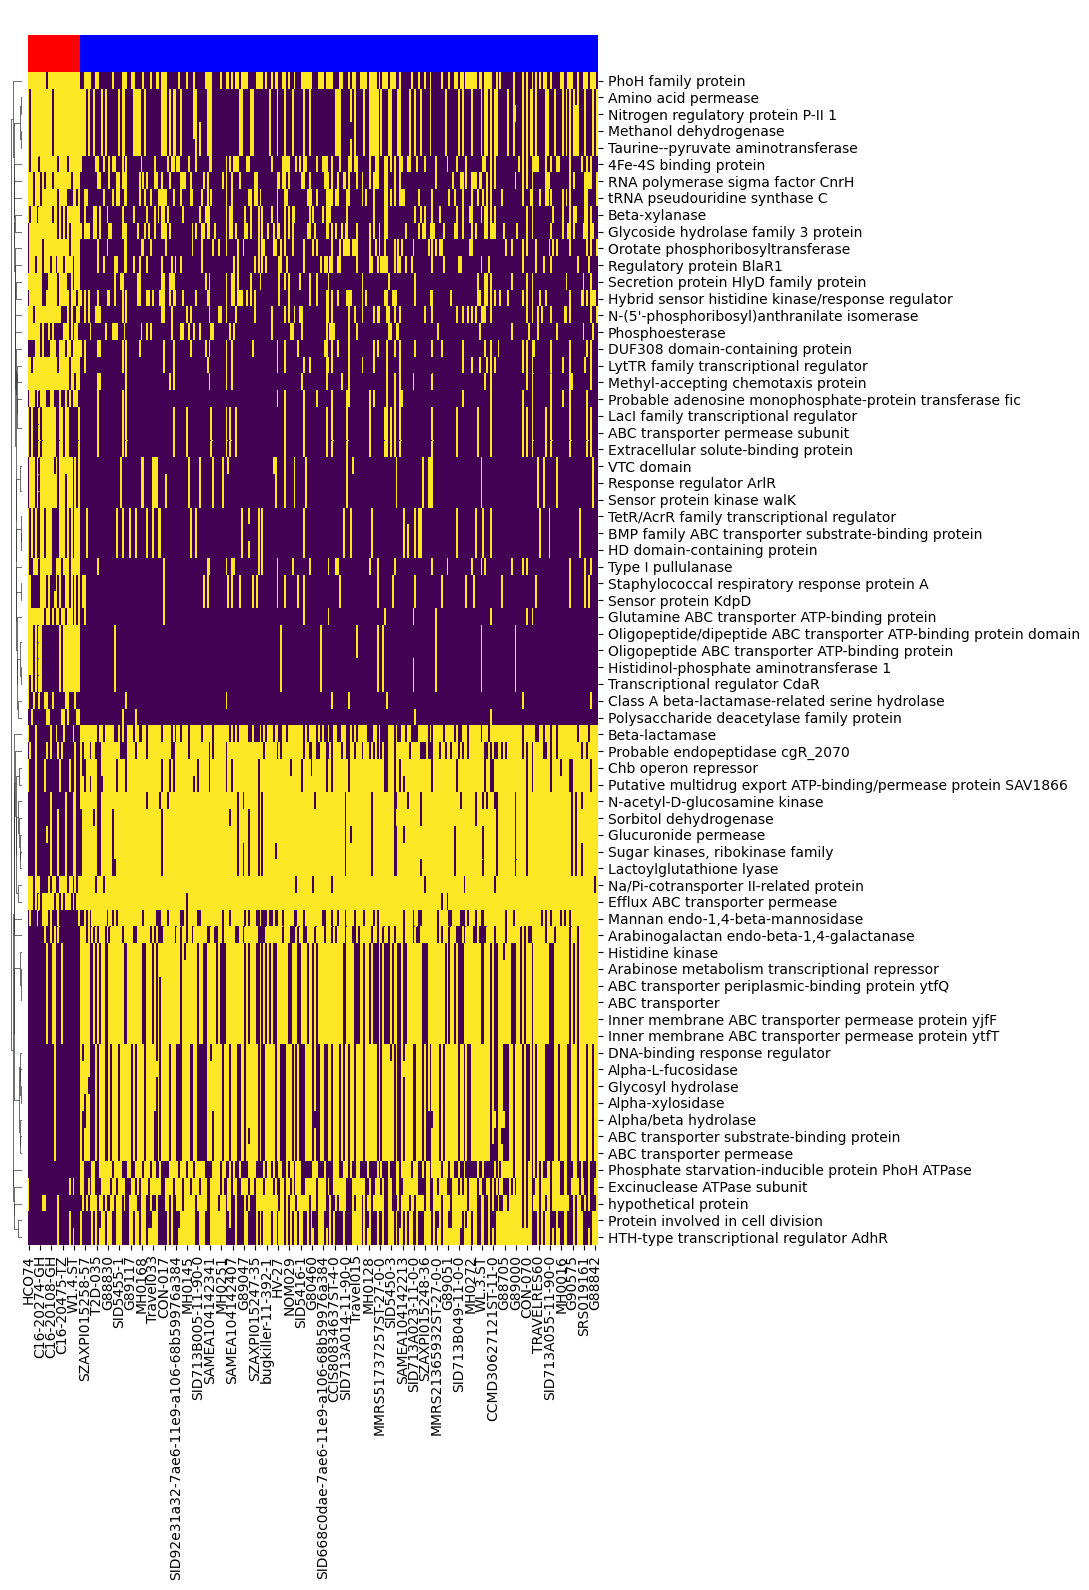

In [27]:
sns.clustermap(df3, col_colors=list(col_cols.values()),figsize=(11, 16),dendrogram_ratio=0.02, cbar_pos=None, col_cluster=False, cmap=sns.color_palette("viridis", as_cmap=True))
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/roseburia_u90.svg')